# 📋 РУКОВОДСТВО ПО ИСПОЛЬЗОВАНИЮ ШАБЛОНА CYCLE COMPARISON

## Просмотр результатов

**Ноутбук уже выполнен.** Все графики и выводы видны сразу при открытии на GitHub.

### Источник данных:

**Датасет:** Stroke Prediction Dataset  
**Источник:** [Kaggle - Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

Навигация: [REDMI.md](https://github.com/vokoder1990/ml_practic/blob/main/stroke-prediction/REDMI.md)

Итоги анализа датасета: [ANALYSIS_REPORT.md](https://github.com/vokoder1990/ml_practic/blob/main/stroke-prediction/ANALYSIS_REPORT.md)

---

## ⚙️ ОСНОВНЫЕ НАСТРОЙКИ (блок 1.2)

| Переменная | Значение | Описание |
|------------|----------|----------|
| **`PROJECT_NAME`** | `'stroke'` | Имя проекта |
| **`MANUAL_WINNER`** | `None` | Ручной выбор цикла (например, `'cycle_3'`) |
| **`EXCLUDED_CYCLES`** | `[]` | Циклы, которые исключаются из выбора |

### 🎯 Критерии отбора (VAL)

| Переменная | Значение | Описание |
|------------|----------|----------|
| `MIN_VAL_RECALL` | `0.85` | Минимальный Recall |
| `MAX_VAL_NNI` | `20` | Максимальный NNI |
| `MAX_VAL_COST` | `1000` | Максимальная Medical Cost |

### 🎯 Критерии приёмки (TEST)

| Переменная | Значение | Описание |
|------------|----------|----------|
| `MIN_TEST_RECALL` | `0.80` | Минимальный Recall |
| `MAX_TEST_NNI` | `25` | Максимальный NNI |
| `MAX_STABILITY_DROP` | `0.10` | Максимальное падение Recall (VAL → TEST) |

---

## 🏆 ВЫБОР ЛУЧШЕЙ МОДЕЛИ (блок 3.3)

| Приоритет | Режим | Условие |
|-----------|-------|---------|
| 1 | **Ручной** | `MANUAL_WINNER` указан и существует |
| 2 | **Автоматический** | Выбирается цикл с минимальным `Medical Cost (CV)` |

**Критерии включения цикла в выбор:**
- `cycle_status = 'VALID'` (успешное modelling)
- Цикл не входит в `EXCLUDED_CYCLES`

---

## 📊 ТЕСТИРОВАНИЕ (блок 4)

### Механизм кэширования

| Ситуация | Действие |
|----------|----------|
| `test_report.json` существует | Данные загружаются из кэша |
| `test_report.json` не существует | TEST запускается, результат сохраняется |

### Критерии приёмки

| Критерий | Условие |
|----------|---------|
| TEST Recall | `≥ MIN_TEST_RECALL` |
| TEST NNI | `≤ MAX_TEST_NNI` |
| Стабильность Recall | `val_recall - test_recall ≤ MAX_STABILITY_DROP` |

**Если все критерии пройдены** → модель копируется в `production/`

---

## 📁 РЕЗУЛЬТАТЫ

### Production (`production/`)

| Файл | Описание |
|------|----------|
| `final_model.joblib` | Финальная модель |
| `final_metadata.json` | Метаданные |
| `scalers.pkl` | Скейлеры признаков |
| `production_report.json` | Отчёт о production-модели |
| `clinical_conclusion.txt` | Заключение для бизнеса |

### Внутри цикла (`cycle_N/modelling/`)

| Файл | Описание |
|------|----------|
| `test_report.json` | Результаты тестирования (кэш) |
| `test_results.png` | Графики (Confusion Matrix + Calibration) |

---

## 📁 СТРУКТУРА ПРОЕКТА ПОСЛЕ ВЫПОЛНЕНИЯ

<pre>
📁 {PROJECT_NAME}/
│
├── 📁 cycle_1/
│   ├── 📁 preprocessing/
│   ├── 📁 eda/
│   └── 📁 modelling/
│
├── 📁 cycle_2/ ...               # другие циклы
│
├── 📄 winner_cycle.json          # информация о победителе
│
└── 📁 production/                # финальный артефакт
    ├── 📄 final_model.joblib
    ├── 📄 scalers.pkl
    ├── 📄 final_metadata.json
    ├── 📄 production_report.json
    ├── 📄 clinical_conclusion.txt
    ├── 📁 plots/                 # все графики
    └── 📁 reports/               # CSV-отчёты
</pre>

---

## ⚠️ ВАЖНО

- TEST запускается **один раз**, результат кэшируется в `test_report.json`
- Результаты TEST **не влияют** на выбор лучшего цикла (выбор только по VAL)
- Production-модель копируется **только если TEST-критерии пройдены**


# СТРУКТУРА ШАБЛОНА CYCLE COMPARISON

**Версия 1.0** (с изоляцией production)

---

## ЧАСТЬ 1: НАСТРОЙКА И ЗАГРУЗКА

| Блок | Название |
|------|----------|
| 1.1 | Импорты и определение окружения |
| 1.2 | Настройки проекта |
| 1.3 | Монтирование Google Drive |

---

## ЧАСТЬ 2: ПОИСК ПРОЕКТА И СБОР VAL-МЕТРИК

| Блок | Название |
|------|----------|
| 2.1 | Настройка путей (с поиском циклов и защитой) |
| 2.2 | Вспомогательные функции |
| 2.3 | Создание папок (внутри production) |

---

## ЧАСТЬ 3: СРАВНЕНИЕ ВСЕХ ЦИКЛОВ VAL

| Блок | Название |
|------|----------|
| 3.1 | Сбор метрик по всем циклам |
| 3.2 | Таблица сравнения циклов (VAL-метрики) |
| 3.3 | Выбор лучшего цикла |

---

## ЧАСТЬ 4: ТЕСТ

| Блок | Название |
|------|----------|
| 4.1 | Запуск TEST для выбранного цикла |
| 4.2 | Проверка TEST-метрик и решение |
| 4.3 | Копирование в production и финальное заключение |

---

## ЧАСТЬ 5: SHAP-АНАЛИЗ

| Блок | Название |
|------|----------|
| 5.1 | SHAP-анализ на TEST данных |
| 5.2 | Сравнение SHAP VAL vs TEST |

---

## ЧАСТЬ 6: PSI И ДРЕЙФ ПРИЗНАКОВ

| Блок | Название |
|------|----------|
| 6.1 | PSI (Population Stability Index) — дрейф признаков |

---

## ЧАСТЬ 7: СРАВНЕНИЕ С DUMMY

| Блок | Название |
|------|----------|
| 7.1 | Сравнение с Dummy на TEST |

---

## ЧАСТЬ 8: КАЛИБРОВКА И ОШИБКИ

| Блок | Название |
|------|----------|
| 8.1 | PR-AUC кривая на TEST |
| 8.2 | Анализ FP (ложные тревоги) на TEST |
| 8.3 | Доверительные интервалы для TEST метрик |
| 8.4 | Сравнение калибровки VAL vs TEST |
| 8.5 | Анализ ошибок на TEST (FN vs TP vs FP) |

---

## РЕЗУЛЬТАТЫ

**Папка `production/` (в корне проекта):**
- `final_model.joblib` — финальная модель для деплоя
- `scalers.pkl` — словарь скейлеров признаков
- `final_metadata.json` — метаданные production модели
- `production_report.json` — отчёт о production модели
- `clinical_conclusion.txt` — текстовое заключение для бизнеса

**Папка `production/plots/`:**
- `test_results.png` — confusion matrix + калибровка на TEST
- `shap_summary_test.png` — SHAP summary plot
- `shap_importance_test.png` — SHAP feature importance
- `shap_comparison.png` — сравнение важности признаков VAL vs TEST
- `pr_curve_test.png` — PR-AUC кривая
- `dummy_comparison_test.png` — сравнение с Dummy
- `calibration_val_test.png` — сравнение калибровки VAL vs TEST

**Папка `production/reports/`:**
- `shap_comparison.csv` — таблица сравнения SHAP
- `psi_val_test.csv` — PSI по каждому признаку
- `fp_analysis.csv` — анализ ложных тревог



# БЛОК 1. ИМПОРТЫ

In [ ]:
# =============================================================================
# 1.1 ИМПОРТЫ И ОПРЕДЕЛЕНИЕ ОКРУЖЕНИЯ
# =============================================================================

import os
import sys
import json
import shutil
import glob
import re
import time
import pandas as pd
import numpy as np
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Метрики
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix,
    brier_score_loss, precision_recall_curve,
    roc_auc_score, roc_curve
)

# Калибровка
from sklearn.calibration import calibration_curve

# Dummy для сравнения
from sklearn.dummy import DummyClassifier

# Статистика
from scipy.stats import beta, norm

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Опционально: SHAP (будет импортирован при использовании)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️ SHAP не установлен. Для SHAP-анализа выполните: pip install shap")

# Определение окружения
try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ Среда выполнения: Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Среда выполнения: локальная")

print("✅ Импорты выполнены")

✓ Среда выполнения: Google Colab
✅ Импорты выполнены


# Настройки проекта

In [ ]:
# =============================================================================
# 1.2 НАСТРОЙКИ ПРОЕКТА
# =============================================================================

PROJECT_NAME = 'stroke'      # имя папки в datasets/

# ============================================
# ПУТИ (зависят от окружения)
# ============================================
if IN_COLAB:
    BASE_PATH = '/content/drive/MyDrive/ml_learning'
else:
    BASE_PATH = os.path.join(os.getcwd(), 'ml_learning')

# =============================================================================
# НАСТРОЙКИ РУЧНОГО ВЫБОРА МОДЕЛИ
# =============================================================================

# ⚠️ РУЧНОЕ УПРАВЛЕНИЕ: укажите здесь, какой цикл победитель
MANUAL_WINNER = None  # Пример: 'cycle_3' или None

# Циклы, которые НЕ должны участвовать в выборе (например, провальные)
EXCLUDED_CYCLES = []  # Пример: [2, 4]

# ============================================
# УРОВЕНЬ 1: ТЕХНИЧЕСКИЕ МЕТРИКИ
# ============================================
FILTER_MIN_BSS = 0.0
FILTER_MAX_STABILITY_GAP = 0.10
FILTER_MAX_MEDICAL_COST_CV_COEF = 0.30

# ============================================
# УРОВЕНЬ 2: КАЛИБРОВКА И КАЧЕСТВО
# ============================================
FILTER_MAX_ECE = 0.10
FILTER_MAX_MCE = 0.15
FILTER_MIN_PR_AUC = 0.08
FILTER_RELIABILITY_SLOPE_MIN = 0.6
FILTER_RELIABILITY_SLOPE_MAX = 1.4

# ============================================
# УРОВЕНЬ 3: КЛИНИЧЕСКИЕ ТРЕБОВАНИЯ (VAL)
# ============================================
MIN_VAL_RECALL = 0.85
MIN_VAL_PRECISION = 0.10
MAX_VAL_SELECTION_RATE = 0.45
MAX_VAL_NNI = 20
MIN_VAL_TP = 5
MIN_VAL_RECALL_LOWER_CI = 0.70
MAX_VAL_COST = 1000

# ============================================
# КРИТЕРИИ ДЛЯ TEST (ПРОВЕРКА ПОСЛЕ ВЫБОРА)
# ============================================
MIN_TEST_RECALL = 0.80
MAX_TEST_NNI = 25
MAX_TEST_COST_INCREASE_PERCENT = 20
MAX_STABILITY_DROP = 0.10

# ============================================
# КЛИНИЧЕСКИЕ НАСТРОЙКИ
# ============================================
TARGET_LABEL = "инсульт"
POSITIVE_CLASS_NAME = "Stroke"
NEGATIVE_CLASS_NAME = "No Stroke"

# ============================================
# НАСТРОЙКИ ВАЛИДАЦИИ (ДОБАВЛЕНО)
# ============================================
# Включить/выключить проверки
VALIDATE_METADATA = True          # проверять ли метаданные циклов
VALIDATE_TEST_FILES = True        # проверять ли наличие TEST-файлов
VALIDATE_PRODUCTION_COPY = True   # проверять ли корректность копирования

# Пороги для предупреждений
WARN_PROBS_STD_THRESHOLD = 0.01   # если std вероятностей ниже — предупреждение
WARN_RECALL_DROP = 0.10           # если Recall упал больше — предупреждение
WARN_COST_INCREASE = 30           # если Cost вырос больше % — предупреждение

# ============================================
# ВЫВОД НАСТРОЕК
# ============================================
print("\n" + "=" * 70)
print("📋 НАСТРОЙКИ ПРОЕКТА ДЛЯ CYCLE COMPARISON")
print("=" * 70)
print(f"   PROJECT_NAME: {PROJECT_NAME}")
print(f"   Ручной победитель: {MANUAL_WINNER if MANUAL_WINNER else '❌ Не задан'}")
print(f"   Исключённые циклы: {EXCLUDED_CYCLES if EXCLUDED_CYCLES else '❌ Нет'}")

print("\n📊 ФИЛЬТРЫ ДЛЯ ВКЛЮЧЕНИЯ ЦИКЛА В СРАВНЕНИЕ:")
print(f"   Статус цикла: только 'VALID' (из modelling)")
print(f"   Исключение по списку EXCLUDED_CYCLES: активен")

print("\n🎯 КРИТЕРИЙ ВЫБОРА ПОБЕДИТЕЛЯ:")
if MANUAL_WINNER == 'manual':
    print(f"   Выбор: ручной (MANUAL_WINNER = {MANUAL_WINNER})")
else:
    print(f"   Выбор: автоматический (по минимальному Medical Cost CV)")

print("\n📊 КРИТЕРИИ ПРИЁМКИ НА TEST:")
print(f"   • Минимальный TEST Recall: {MIN_TEST_RECALL * 100:.0f}%")
print(f"   • Максимальный TEST NNI: {MAX_TEST_NNI}")
print(f"   • Максимальный рост Cost: {MAX_TEST_COST_INCREASE_PERCENT}%")

print("\n🔧 ДОПОЛНИТЕЛЬНЫЕ ПРОВЕРКИ:")
print(f"   Валидация метаданных: {'✅' if VALIDATE_METADATA else '❌'}")
print(f"   Валидация TEST файлов: {'✅' if VALIDATE_TEST_FILES else '❌'}")
print(f"   Валидация production копии: {'✅' if VALIDATE_PRODUCTION_COPY else '❌'}")
print(f"   Порог предупреждения по вероятностям: {WARN_PROBS_STD_THRESHOLD}")

print("=" * 70 + "\n")


📋 НАСТРОЙКИ ПРОЕКТА ДЛЯ CYCLE COMPARISON
   PROJECT_NAME: stroke
   Ручной победитель: ❌ Не задан
   Исключённые циклы: ❌ Нет

📊 ФИЛЬТРЫ ДЛЯ ВКЛЮЧЕНИЯ ЦИКЛА В СРАВНЕНИЕ:
   Статус цикла: только 'VALID' (из modelling)
   Исключение по списку EXCLUDED_CYCLES: активен

🎯 КРИТЕРИЙ ВЫБОРА ПОБЕДИТЕЛЯ:
   Выбор: автоматический (по минимальному Medical Cost CV)

📊 КРИТЕРИИ ПРИЁМКИ НА TEST:
   • Минимальный TEST Recall: 80%
   • Максимальный TEST NNI: 25
   • Максимальный рост Cost: 20%

🔧 ДОПОЛНИТЕЛЬНЫЕ ПРОВЕРКИ:
   Валидация метаданных: ✅
   Валидация TEST файлов: ✅
   Валидация production копии: ✅
   Порог предупреждения по вероятностям: 0.01



In [ ]:
# =============================================================================
# 1.3 МОНТИРОВАНИЕ GOOGLE DRIVE
# =============================================================================

print("\n" + "=" * 50)
print("📂 МОНТИРОВАНИЕ GOOGLE DRIVE")
print("=" * 50)

if IN_COLAB:
    if BASE_PATH.startswith('/content/drive'):
        if os.path.ismount('/content/drive'):
            print("✓ Google Drive уже смонтирован")
        else:
            print("📂 Монтирование Google Drive...")

            # Если есть папка /content/drive, но она НЕ точка монтирования
            if os.path.exists('/content/drive') and not os.path.ismount('/content/drive'):
                backup_name = f'/content/drive_backup_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
                print(f"   ⚠️ Обнаружена папка /content/drive (не точка монтирования)")
                print(f"   Перемещаем в {backup_name}")
                shutil.move('/content/drive', backup_name)

            # Монтируем Google Drive с обработкой ошибок
            try:
                drive.mount('/content/drive')
                print("✓ Google Drive смонтирован")
            except Exception as e:
                print(f"\n❌ ОШИБКА МОНТИРОВАНИЯ: {e}")
                print("   Возможные причины:")
                print("   • Нет подключения к интернету")
                print("   • Нет прав доступа к Google Drive")
                print("   • Проблемы с авторизацией")
                print("\n   💡 Решение:")
                print("   • Проверьте интернет-соединение")
                print("   • Перезапустите среду выполнения (Runtime → Restart runtime)")
                print("   • При монтировании нажмите на ссылку и скопируйте код авторизации")
                raise  # Останавливаем выполнение
    else:
        print("✓ BASE_PATH не на Google Drive, монтирование не требуется")
else:
    print("✓ Локальная среда, монтирование не требуется")

print("=" * 50 + "\n")


📂 МОНТИРОВАНИЕ GOOGLE DRIVE
📂 Монтирование Google Drive...
Mounted at /content/drive
✓ Google Drive смонтирован



# БЛОК 2. ПОИСК ПРОЕКТА И СБОР VAL-МЕТРИК

In [ ]:
# =============================================================================
# 2.1 НАСТРОЙКА ПУТЕЙ (С ПОИСКОМ ЦИКЛОВ И ЗАЩИТОЙ)
# =============================================================================

print("\n" + "=" * 70)
print("📂 НАСТРОЙКА ПУТЕЙ")
print("=" * 70)

# --------------------------------------------
# ПРОВЕРКА СУЩЕСТВОВАНИЯ ПРОЕКТА
# --------------------------------------------
PROJECT_PATH = os.path.join(BASE_PATH, 'datasets', PROJECT_NAME)

if not os.path.exists(PROJECT_PATH):
    raise FileNotFoundError(
        f"\n❌ ПРОЕКТ НЕ НАЙДЕН: {PROJECT_PATH}\n"
        f"   Убедитесь, что:\n"
        f"   1. PROJECT_NAME указан правильно\n"
        f"   2. Preprocessing для цикла 1 выполнен\n"
        f"   3. Пути настроены корректно"
    )

# --------------------------------------------
# ПОИСК ВСЕХ ЦИКЛОВ В ПРОЕКТЕ
# --------------------------------------------
cycle_pattern = os.path.join(PROJECT_PATH, 'cycle_*')
cycle_folders = glob.glob(cycle_pattern)

cycle_numbers = []
for folder in cycle_folders:
    folder_name = os.path.basename(folder)
    match = re.match(r'cycle_(\d+)', folder_name)
    if match:
        cycle_numbers.append(int(match.group(1)))

cycle_numbers = sorted(cycle_numbers)

print(f"\n📊 НАЙДЕННЫЕ ЦИКЛЫ:")
if cycle_numbers:
    print(f"   Циклы с данными: {cycle_numbers}")
    print(f"   Всего циклов: {len(cycle_numbers)}")
else:
    print(f"   ⚠️ НЕ НАЙДЕНО НИ ОДНОГО ЦИКЛА!")
    print(f"   Искали по шаблону: {cycle_pattern}")
    raise SystemExit(0)

# --------------------------------------------
# ЗАЩИТА ОТ ПЕРЕЗАПИСИ PRODUCTION
# --------------------------------------------
PRODUCTION_PATH = os.path.join(PROJECT_PATH, 'production')

if os.path.exists(PRODUCTION_PATH):
    print(f"\n⚠️ ВНИМАНИЕ: Папка production уже существует!")
    print(f"   {PRODUCTION_PATH}")

    existing_files = os.listdir(PRODUCTION_PATH)
    if existing_files:
        print(f"   Обнаружены существующие файлы: {existing_files[:5]}...")
        if 'final_model.joblib' in existing_files:
            print("   ⚠️ ВНИМАНИЕ: Обнаружена production модель! Перезапись удалит её.")

    print(f"\n   Что делать:")
    print(f"   • Если хотите ПЕРЕЗАПИСАТЬ production — введите 'y'")
    print(f"   • Если хотите сохранить существующий production — введите 'n'")

    response = input(f"\n   Продолжить с перезаписью? (y/N): ")
    if response.lower() != 'y':
        print("❌ Операция отменена. Production не тронут.")
        raise SystemExit(0)
    else:
        print(f"   ⚠️ Продолжаем с перезаписью production")
        shutil.rmtree(PRODUCTION_PATH)
        print(f"   🗑️ Старая папка production удалена")

# Создаём папку production заново
os.makedirs(PRODUCTION_PATH, exist_ok=True)

print(f"\n📁 Проект: {PROJECT_NAME}")
print(f"📂 PROJECT_PATH: {PROJECT_PATH}")
print(f"📂 PRODUCTION_PATH: {PRODUCTION_PATH}")
print(f"📊 Найдено циклов: {len(cycle_numbers)}")

print("\n" + "=" * 70)
print("✅ Пути настроены, production защищён от случайной перезаписи")
print("=" * 70 + "\n")


📂 НАСТРОЙКА ПУТЕЙ

📊 НАЙДЕННЫЕ ЦИКЛЫ:
   Циклы с данными: [1, 2, 3, 4, 5]
   Всего циклов: 5

📁 Проект: stroke
📂 PROJECT_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke
📂 PRODUCTION_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/production
📊 Найдено циклов: 5

✅ Пути настроены, production защищён от случайной перезаписи



In [ ]:
# =============================================================================
# 2.2 ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =============================================================================

def convert_to_serializable(obj):
    """Рекурсивно конвертирует numpy-типы в Python-типы для JSON"""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Series):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj


def brier_skill_score(y_true, y_probs):
    """Brier Skill Score."""
    bs_model = brier_score_loss(y_true, y_probs)
    p_mean = np.mean(y_true)
    bs_climatology = brier_score_loss(y_true, np.full_like(y_true, p_mean))
    if bs_climatology == 0:
        return 0.0
    return 1 - (bs_model / bs_climatology)


def calculate_medical_cost(fn, fp, cost_fn, cost_fp):
    """Рассчитывает Medical Cost."""
    return fn * cost_fn + fp * cost_fp


def calculate_nni(precision):
    """Number Needed to Inspect."""
    if precision > 0:
        return 1 / precision
    return float('inf')


def recall_confidence_interval(tp, fn, confidence=0.95):
    """Доверительный интервал для Recall."""
    n = tp + fn
    if n == 0:
        return 0.0, 0.0
    alpha = tp + 1
    beta_param = fn + 1
    lower = beta.ppf((1 - confidence) / 2, alpha, beta_param)
    upper = beta.ppf(1 - (1 - confidence) / 2, alpha, beta_param)
    return lower, upper


def validate_cycle_metadata(metadata_path):
    """
    Проверяет, что метаданные цикла содержат все необходимые поля.

    Возвращает:
    --------
    is_valid : bool
    missing_fields : list
    """
    required_fields = [
        'cycle_number', 'model_name', 'threshold',
        'val_metrics', 'feature_names', 'cost_fn', 'cost_fp'
    ]

    if not os.path.exists(metadata_path):
        return False, [f"Файл не найден: {metadata_path}"]

    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    missing = [field for field in required_fields if field not in metadata]

    if missing:
        return False, missing

    # Проверка val_metrics
    val_metrics_required = ['recall', 'precision', 'medical_cost', 'nni', 'tp', 'fn', 'fp']
    if 'val_metrics' in metadata:
        missing_val = [f for f in val_metrics_required if f not in metadata['val_metrics']]
        if missing_val:
            return False, [f"val_metrics missing: {missing_val}"]

    return True, []


def validate_test_data(cycle_modelling_path):
    """
    Проверяет наличие всех необходимых файлов для TEST.

    Возвращает:
    --------
    is_valid : bool
    missing_files : list
    """
    required_files = [
        os.path.join(cycle_modelling_path, 'final_model.joblib'),
        os.path.join(cycle_modelling_path, 'final_metadata.json'),
        os.path.join(cycle_modelling_path, 'splits', 'X_test_scaled.csv'),
        os.path.join(cycle_modelling_path, 'splits', 'y_test.csv')
    ]

    missing = [f for f in required_files if not os.path.exists(f)]

    return len(missing) == 0, missing


def validate_production_copy(source_dir, dest_dir):
    """
    Проверяет, что production-файлы скопированы корректно.
    """
    required_files = ['final_model.joblib', 'final_metadata.json']
    if os.path.exists(os.path.join(source_dir, 'scalers.pkl')):
        required_files.append('scalers.pkl')

    missing = []
    for f in required_files:
        src = os.path.join(source_dir, f)
        dst = os.path.join(dest_dir, f)
        if not os.path.exists(dst):
            missing.append(f)
        elif os.path.getsize(src) != os.path.getsize(dst):
            missing.append(f"{f} (размер не совпадает)")

    return len(missing) == 0, missing


def load_model_and_data(modelling_path, splits_path, feature_names):
    """Загружает модель и TEST данные."""
    model = joblib.load(os.path.join(modelling_path, 'final_model.joblib'))
    X_test = pd.read_csv(os.path.join(splits_path, 'X_test_scaled.csv'))
    y_test = pd.read_csv(os.path.join(splits_path, 'y_test.csv'))
    if y_test.shape[1] > 1:
        y_test = y_test.iloc[:, 0]
    else:
        y_test = y_test.squeeze()
    X_test = X_test[feature_names]
    return model, X_test, y_test


def calculate_test_metrics(y_test, y_pred, test_probs, cost_fn, cost_fp):
    """Рассчитывает все TEST-метрики."""
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    nni = calculate_nni(precision)
    cost = calculate_medical_cost(fn, fp, cost_fn, cost_fp)
    pr_auc = average_precision_score(y_test, test_probs)
    bss = brier_skill_score(y_test, test_probs)
    rec_lower, rec_upper = recall_confidence_interval(tp, fn)
    selection_rate = (tp + fp) / len(y_test) * 100
    return {
        'recall': recall, 'precision': precision, 'f1': f1,
        'nni': nni, 'medical_cost': cost, 'pr_auc': pr_auc,
        'bss': bss, 'selection_rate': selection_rate,
        'recall_ci_lower': rec_lower, 'recall_ci_upper': rec_upper,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }


print("✅ Вспомогательные функции загружены")

✅ Вспомогательные функции загружены


In [ ]:
# =============================================================================
# 2.3 СОЗДАНИЕ ПАПОК (внутри production)
# =============================================================================

print("\n" + "=" * 50)
print("📁 СОЗДАНИЕ ПАПОК")
print("=" * 50)

# Папка production уже создана в блоке 2.1 (с защитой от перезаписи)
# Здесь создаём внутренние подпапки

PRODUCTION_PLOTS_PATH = os.path.join(PRODUCTION_PATH, 'plots')
os.makedirs(PRODUCTION_PLOTS_PATH, exist_ok=True)

print(f"   📂 PRODUCTION_PATH: {PRODUCTION_PATH}")
print(f"   📂 PRODUCTION_PLOTS_PATH: {PRODUCTION_PLOTS_PATH}")

print("✅ Папки созданы")
print("=" * 50 + "\n")


📁 СОЗДАНИЕ ПАПОК
   📂 PRODUCTION_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/production
   📂 PRODUCTION_PLOTS_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots
✅ Папки созданы



# БЛОК 3. СРАВНЕНИЕ ВСЕХ ЦИКЛОВ VAL

In [ ]:
# =============================================================================
# 3.1 СБОР МЕТРИК ПО ВСЕМ ЦИКЛАМ
# =============================================================================

print("\n" + "=" * 70)
print("📊 СБОР МЕТРИК ПО ВСЕМ ЦИКЛАМ")
print("=" * 70)

cycles_data = []

# Определяем диапазон циклов для поиска
cycles_to_check = range(1, CYCLE_NUMBER + 1) if 'CYCLE_NUMBER' in globals() else range(1, 100)

for cycle in cycles_to_check:
    cycle_path = os.path.join(PROJECT_PATH, f'cycle_{cycle}')
    modelling_path = os.path.join(cycle_path, 'modelling')
    metadata_path = os.path.join(modelling_path, 'final_metadata.json')

    if not os.path.exists(metadata_path):
        continue

    with open(metadata_path, 'r') as f:
        meta = json.load(f)

    # Проверяем статус цикла (только VALID участвуют)
    cycle_status = meta.get('cycle_status', 'UNKNOWN')

    # Пропускаем невалидные циклы
    if cycle_status != 'VALID':
        print(f"   ⚠️ Цикл {cycle}: статус '{cycle_status}' → пропущен")
        continue

    # Пропускаем исключённые циклы
    if cycle in EXCLUDED_CYCLES:
        print(f"   ⚠️ Цикл {cycle}: в списке EXCLUDED_CYCLES → пропущен")
        continue

    # Извлекаем метрики
    if meta.get('has_winner', False):
        cycles_data.append({
            'cycle': f'cycle_{cycle}',
            'cycle_number': cycle,
            'model_name': meta.get('model_name', 'N/A'),
            'medical_cost_cv': meta['val_metrics']['medical_cost_cv'],
            'medical_cost_val': meta['val_metrics']['medical_cost'],
            'recall': meta['val_metrics']['recall'],
            'recall_lower_ci': meta['val_metrics'].get('recall_lower_ci', 0.0),
            'precision': meta['val_metrics']['precision'],
            'selection_rate': meta['val_metrics']['selection_rate'],
            'nni': meta['val_metrics']['nni'],
            'threshold': meta.get('final_threshold', meta.get('threshold', 0.5)),
            'status': cycle_status,
            'stability_std': meta.get('stability_check', {}).get('std_recall', None)
        })
        print(f"   ✅ Цикл {cycle}: {meta['model_name']} (RECALL={meta['val_metrics']['recall']:.3f})")

df_cycles = pd.DataFrame(cycles_data)

if len(df_cycles) == 0:
    print("\n❌ Нет валидных циклов для сравнения!")
    raise SystemExit(0)

print(f"\n📊 Найдено валидных циклов: {len(df_cycles)}")


📊 СБОР МЕТРИК ПО ВСЕМ ЦИКЛАМ
   ⚠️ Цикл 1: статус 'NO_MODEL' → пропущен
   ✅ Цикл 2: FN18_L2_C=0.1 (RECALL=0.840)
   ✅ Цикл 3: FN17_L2_C=0.1 (RECALL=0.840)
   ⚠️ Цикл 4: статус 'NO_MODEL' → пропущен
   ✅ Цикл 5: FN17_L2_C=1 (RECALL=0.860)

📊 Найдено валидных циклов: 3


In [ ]:
# =============================================================================
# 3.2 ТАБЛИЦА СРАВНЕНИЯ ЦИКЛОВ (VAL-МЕТРИКИ)
# =============================================================================

print("\n" + "=" * 110)
print("📊 VAL-МЕТРИКИ ВСЕХ ЦИКЛОВ")
print("=" * 110)

# Определяем, какой DataFrame использовать
if 'df_val' in globals() and len(df_val) > 0:
    df_to_show = df_val
elif 'df_cycles' in globals() and len(df_cycles) > 0:
    df_to_show = df_cycles
    print("ℹ️ Используем df_cycles (переименуйте в df_val для единообразия)")
else:
    print("❌ НЕТ ДАННЫХ ДЛЯ ОТОБРАЖЕНИЯ!")
    print("   Выполните блок 3.1 (сбор метрик циклов)")
    raise SystemExit(0)

if len(df_to_show) == 0:
    print("❌ НЕТ ДАННЫХ ДЛЯ ОТОБРАЖЕНИЯ!")
    raise SystemExit(0)

# Выбираем колонки для отображения (с учётом возможных имён)
display_cols = [
    'cycle_number', 'model_name',
    'val_recall', 'val_precision', 'val_cost', 'medical_cost_cv', 'val_nni', 'val_selection_rate',
    'medical_cost_cv_coef', 'pr_auc', 'ece'
]

# Проверяем альтернативные имена колонок
if 'recall' in df_to_show.columns and 'val_recall' not in df_to_show.columns:
    df_to_show['val_recall'] = df_to_show['recall']
if 'medical_cost' in df_to_show.columns and 'val_cost' not in df_to_show.columns:
    df_to_show['val_cost'] = df_to_show['medical_cost']
if 'selection_rate' in df_to_show.columns and 'val_selection_rate' not in df_to_show.columns:
    df_to_show['val_selection_rate'] = df_to_show['selection_rate']

# Проверяем, какие колонки есть в df_to_show
available_cols = [col for col in display_cols if col in df_to_show.columns]
display_df = df_to_show[available_cols].copy()

# Форматирование
if 'val_recall' in display_df.columns:
    display_df['val_recall'] = display_df['val_recall'].apply(lambda x: f"{x:.3f}")
if 'val_precision' in display_df.columns:
    display_df['val_precision'] = display_df['val_precision'].apply(lambda x: f"{x:.3f}")
if 'val_cost' in display_df.columns:
    display_df['val_cost'] = display_df['val_cost'].apply(lambda x: f"{int(x):,}")
if 'medical_cost_cv' in display_df.columns:
    display_df['medical_cost_cv'] = display_df['medical_cost_cv'].apply(lambda x: f"{int(x):,}")
if 'val_nni' in display_df.columns:
    display_df['val_nni'] = display_df['val_nni'].apply(lambda x: f"{x:.1f}")
if 'val_selection_rate' in display_df.columns:
    display_df['val_selection_rate'] = display_df['val_selection_rate'].apply(lambda x: f"{x:.1f}%")

if 'medical_cost_cv_coef' in display_df.columns:
    display_df['medical_cost_cv_coef'] = display_df['medical_cost_cv_coef'].apply(lambda x: f"{x:.3f}")
if 'pr_auc' in display_df.columns:
    display_df['pr_auc'] = display_df['pr_auc'].apply(lambda x: f"{x:.3f}")
if 'ece' in display_df.columns:
    display_df['ece'] = display_df['ece'].apply(lambda x: f"{x:.3f}")

# Переименовываем колонки для читаемости
column_rename = {
    'cycle_number': 'Цикл',
    'model_name': 'Модель',
    'val_recall': 'Recall',
    'val_precision': 'Precision',
    'val_cost': 'Medical Cost (VAL)',
    'medical_cost_cv': 'Medical Cost (CV)',
    'val_nni': 'NNI',
    'val_selection_rate': 'Sel Rate',
    'medical_cost_cv_coef': 'Cost Coef (стаб)',
    'pr_auc': 'PR-AUC',
    'ece': 'ECE'
}
display_df = display_df.rename(columns=column_rename)

print("\n" + display_df.to_string(index=False))

print("\n" + "-" * 110)
print(f"📌 ВСЕГО ЦИКЛОВ: {len(df_to_show)}")
print(f"   Выбор лучшего цикла производится в блоке 3.3")
print(f"   Критерии: стабильность (Cost Coef ≤ 0.30) + минимальный Medical Cost (CV)")
print("-" * 110)

print("=" * 110 + "\n")


📊 VAL-МЕТРИКИ ВСЕХ ЦИКЛОВ
ℹ️ Используем df_cycles (переименуйте в df_val для единообразия)

 Цикл        Модель Recall Medical Cost (CV) Sel Rate
    2 FN18_L2_C=0.1  0.840               241    30.0%
    3 FN17_L2_C=0.1  0.840               233    29.7%
    5   FN17_L2_C=1  0.860               229    32.4%

--------------------------------------------------------------------------------------------------------------
📌 ВСЕГО ЦИКЛОВ: 3
   Выбор лучшего цикла производится в блоке 3.3
   Критерии: стабильность (Cost Coef ≤ 0.30) + минимальный Medical Cost (CV)
--------------------------------------------------------------------------------------------------------------



# Лучшая модель по val

In [ ]:
# =============================================================================
# 3.3 ВЫБОР ЛУЧШЕГО ЦИКЛА (С УЧЁТОМ РУЧНОГО УПРАВЛЕНИЯ)
# =============================================================================

print("\n" + "=" * 70)
print("🏆 ВЫБОР ЛУЧШЕГО ЦИКЛА")
print("=" * 70)

# Ручной выбор
if MANUAL_WINNER and MANUAL_WINNER in df_cycles['cycle'].values:
    best_cycle = MANUAL_WINNER
    best_row = df_cycles[df_cycles['cycle'] == best_cycle].iloc[0]
    print(f"\n👤 РУЧНОЙ ВЫБОР: цикл {best_cycle}")
    print(f"   Модель: {best_row['model_name']}")
    print(f"   Recall: {best_row['recall']:.3f} (нижн. гр.: {best_row['recall_lower_ci']:.3f})")
    print(f"   Medical Cost CV: {best_row['medical_cost_cv']:.0f}")

# Автоматический выбор (по Medical Cost CV)
else:
    if MANUAL_WINNER:
        print(f"\n⚠️ Ручной победитель '{MANUAL_WINNER}' не найден среди валидных циклов")
        print(f"   Доступные циклы: {df_cycles['cycle'].tolist()}")

    best_row = df_cycles.sort_values('medical_cost_cv').iloc[0]
    best_cycle = best_row['cycle']
    print(f"\n🤖 АВТОМАТИЧЕСКИЙ ВЫБОР: цикл {best_cycle}")
    print(f"   Модель: {best_row['model_name']}")
    print(f"   Recall: {best_row['recall']:.3f} (нижн. гр.: {best_row['recall_lower_ci']:.3f})")
    print(f"   Medical Cost CV: {best_row['medical_cost_cv']:.0f}")

print("\n" + "=" * 70)
print(f"🏆 ПОБЕДИТЕЛЬ: {best_cycle}")
print("=" * 70)

# Сохраняем победителя
winner_metadata_path = os.path.join(PROJECT_PATH, 'winner_cycle.json')
with open(winner_metadata_path, 'w') as f:
    json.dump({
        'winner_cycle': best_cycle,
        'cycle_number': int(best_cycle.split('_')[1]),
        'selection_mode': 'manual' if MANUAL_WINNER else 'auto',
        'selected_at': datetime.now().isoformat(),
        'metrics': {
            'recall': float(best_row['recall']),
            'recall_lower_ci': float(best_row['recall_lower_ci']),
            'medical_cost_cv': float(best_row['medical_cost_cv']),
            'selection_rate': float(best_row['selection_rate']),
            'nni': float(best_row['nni'])
        }
    }, f, indent=2, ensure_ascii=False)

print(f"\n💾 Информация о победителе сохранена: {winner_metadata_path}")


🏆 ВЫБОР ЛУЧШЕГО ЦИКЛА

🤖 АВТОМАТИЧЕСКИЙ ВЫБОР: цикл cycle_5
   Модель: FN17_L2_C=1
   Recall: 0.860 (нижн. гр.: 0.737)
   Medical Cost CV: 229

🏆 ПОБЕДИТЕЛЬ: cycle_5

💾 Информация о победителе сохранена: /content/drive/MyDrive/ml_learning/datasets/stroke/winner_cycle.json


# БЛОК 4. ТЕСТ


🔮 ЗАПУСК TEST ДЛЯ cycle_5 (ПЕРВОЕ ОБРАЩЕНИЕ!)

✅ TEST завершён

📊 TEST-МЕТРИКИ:
   Recall:     0.840  (VAL: 0.860, Δ=-0.020)
   Precision:  0.128
   F1:         0.223
   NNI:        7.8
   Cost (TEST): 421  (VAL: 404, CV: 229)
   PR-AUC:     0.2241
   BSS:        0.1375
   Selection:  32.3%
   TP=42, FP=285, FN=8, TN=676

💾 Отчёт сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/modelling/test_report.json

📊 Создание графиков...
✅ График скопирован в production: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots/test_results.png


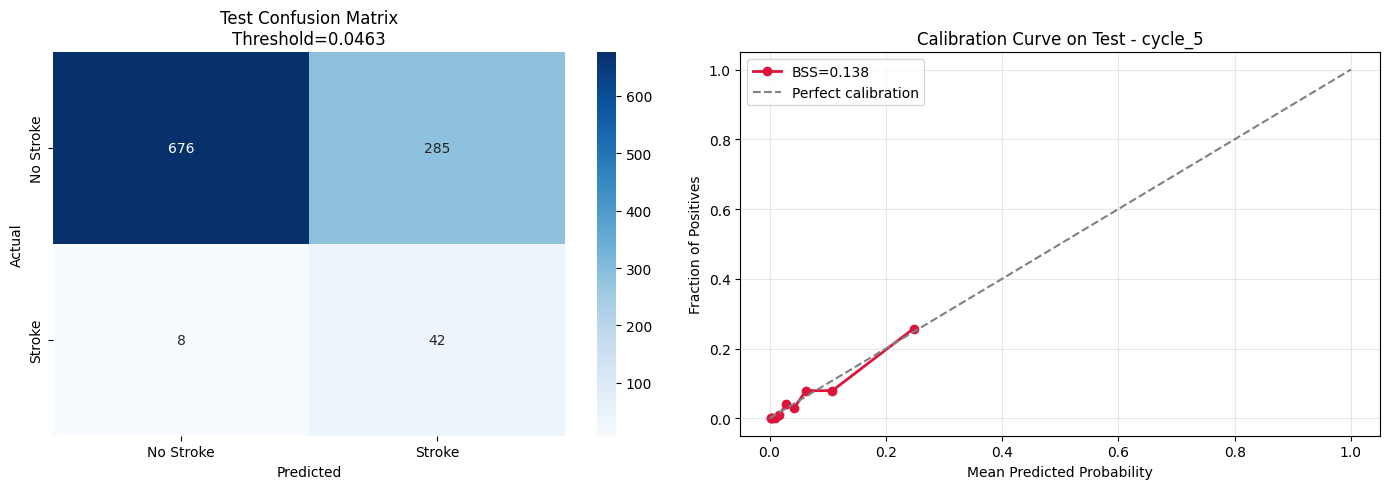

✅ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/modelling/test_results.png

📊 КРИТЕРИИ ПРИЁМКИ МОДЕЛИ
   ✅ TEST Recall: 0.840 ≥ 0.800
   ✅ TEST NNI: 7.8 ≤ 25
   ✅ Рост Cost: 4.2% ≤ 20%

----------------------------------------------------------------------

✅ МОДЕЛЬ ПРОШЛА ТЕСТИРОВАНИЕ!
   Можно переходить к production.

📌 PROCEED_TO_PRODUCTION = True


In [ ]:
# =============================================================================
# 4.1 ЗАПУСК TEST ДЛЯ ВЫБРАННОГО ЦИКЛА
# =============================================================================

# Определяем BEST_CYCLE, если ещё не определён
if 'BEST_CYCLE' not in globals() or BEST_CYCLE is None:
    if 'best_cycle' in globals() and best_cycle is not None:
        BEST_CYCLE = best_cycle
    elif 'selected_cycle' in globals() and selected_cycle is not None:
        BEST_CYCLE = selected_cycle
    elif 'winner_cycle' in globals() and winner_cycle is not None:
        BEST_CYCLE = winner_cycle
    else:
        winner_path = os.path.join(PROJECT_PATH, 'winner_cycle.json')
        if os.path.exists(winner_path):
            with open(winner_path, 'r') as f:
                winner_data = json.load(f)
            BEST_CYCLE = winner_data.get('winner_cycle')
            print(f"ℹ️ Загружен BEST_CYCLE из файла: {BEST_CYCLE}")
        else:
            BEST_CYCLE = None
            print("⚠️ BEST_CYCLE не определён")

PROCEED_TO_PRODUCTION = False

if BEST_CYCLE is None:
    print("\n⏸️ Нет цикла для тестирования.")
    print("   Выполните блок 3.3 (выбор лучшего цикла)")
else:
    # ПУТИ
    cycle_modelling_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'modelling')
    cycle_eda_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data')  # ← ТЕСТОВЫЕ ФАЙЛЫ ЗДЕСЬ
    test_report_path = os.path.join(cycle_modelling_path, 'test_report.json')

    # Проверка наличия тестовых файлов в EDA
    test_x_path = os.path.join(cycle_eda_data_path, 'X_test_scaled.csv')
    test_y_path = os.path.join(cycle_eda_data_path, 'y_test.csv')

    if not os.path.exists(test_x_path):
        raise FileNotFoundError(f"❌ X_test_scaled.csv не найден: {test_x_path}")
    if not os.path.exists(test_y_path):
        raise FileNotFoundError(f"❌ y_test.csv не найден: {test_y_path}")

    # Загружаем метаданные
    metadata_path = os.path.join(cycle_modelling_path, 'final_metadata.json')
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"❌ metadata.json не найден: {metadata_path}")

    with open(metadata_path, 'r') as f:
        metadata = json.load(f)

    feature_names = metadata['feature_names']
    threshold = metadata.get('final_threshold', metadata.get('threshold', 0.5))
    cost_fn = metadata['cost_fn']
    cost_fp = metadata['cost_fp']
    val_recall = metadata['val_metrics']['recall']
    val_cost = metadata['val_metrics']['medical_cost']

    # Загружаем модель
    model_path = os.path.join(cycle_modelling_path, 'final_model.joblib')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"❌ final_model.joblib не найден: {model_path}")

    model = joblib.load(model_path)

    # Загружаем тестовые данные
    X_test = pd.read_csv(test_x_path)
    y_test = pd.read_csv(test_y_path).iloc[:, 0]

    # ========================================
    # ПРОВЕРКА КЭША
    # ========================================
    if os.path.exists(test_report_path):
        print(f"\n✅ TEST уже был запущен для {BEST_CYCLE}")
        with open(test_report_path, 'r') as f:
            test_report = json.load(f)

        test_metrics = test_report['test_metrics']
        test_recall = test_metrics['recall']
        test_cost = test_metrics['medical_cost']
        test_nni = test_metrics['nni']
        test_probs = test_metrics.get('_probs', None)
        y_pred = test_metrics.get('_y_pred', None)

        # Если вероятности не сохранены — пересчитываем
        if test_probs is None or y_pred is None:
            test_probs = model.predict_proba(X_test)[:, 1]
            y_pred = (test_probs >= threshold).astype(int)

        medical_cost_cv = metadata.get('val_metrics', {}).get('medical_cost_cv', None)
        cost_cv_str = f"{medical_cost_cv:.0f}" if medical_cost_cv is not None else "N/A"

        print(f"\n📊 TEST-МЕТРИКИ (из кэша):")
        print(f"   Recall: {test_recall:.3f}, Cost (TEST): {test_cost:.0f}, Cost (CV): {cost_cv_str}, NNI: {test_nni:.1f}")

    else:
        print(f"\n🔮 ЗАПУСК TEST ДЛЯ {BEST_CYCLE} (ПЕРВОЕ ОБРАЩЕНИЕ!)")

        # Предсказания
        test_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (test_probs >= threshold).astype(int)

        # Проверка качества предсказаний
        if test_probs.std() < 0.01:
            print("\n⚠️ ПРЕДУПРЕЖДЕНИЕ: Все предсказанные вероятности почти одинаковы!")
            print(f"   std = {test_probs.std():.6f}")

        # Расчёт метрик
        test_metrics = calculate_test_metrics(y_test, y_pred, test_probs, cost_fn, cost_fp)

        test_recall = test_metrics['recall']
        test_cost = test_metrics['medical_cost']
        test_nni = test_metrics['nni']
        recall_delta = test_recall - val_recall
        cost_delta = test_cost - val_cost

        # Формируем отчёт
        test_report = {
            'cycle': BEST_CYCLE,
            'timestamp': datetime.now().isoformat(),
            'model_name': metadata['model_name'],
            'threshold': threshold,
            'test_metrics': convert_to_serializable(test_metrics),
            'val_metrics': {
                'recall': val_recall,
                'precision': metadata['val_metrics']['precision'],
                'medical_cost': val_cost
            },
            'stability': {
                'recall_delta': recall_delta,
                'cost_delta': cost_delta
            }
        }

        with open(test_report_path, 'w') as f:
            json.dump(test_report, f, indent=2)

        medical_cost_cv = metadata.get('val_metrics', {}).get('medical_cost_cv', None)
        cost_cv_str = f"{medical_cost_cv:.0f}" if medical_cost_cv is not None else "N/A"

        print(f"\n✅ TEST завершён")
        print(f"\n📊 TEST-МЕТРИКИ:")
        print(f"   Recall:     {test_recall:.3f}  (VAL: {val_recall:.3f}, Δ={recall_delta:+.3f})")
        print(f"   Precision:  {test_metrics['precision']:.3f}")
        print(f"   F1:         {test_metrics['f1']:.3f}")
        print(f"   NNI:        {test_nni:.1f}")
        print(f"   Cost (TEST): {test_cost:.0f}  (VAL: {val_cost:.0f}, CV: {cost_cv_str})")
        print(f"   PR-AUC:     {test_metrics['pr_auc']:.4f}")
        print(f"   BSS:        {test_metrics['bss']:.4f}")
        print(f"   Selection:  {test_metrics['selection_rate']:.1f}%")
        print(f"   TP={test_metrics['tp']}, FP={test_metrics['fp']}, FN={test_metrics['fn']}, TN={test_metrics['tn']}")
        print(f"\n💾 Отчёт сохранён: {test_report_path}")

    # ========================================
    # ВИЗУАЛИЗАЦИЯ
    # ========================================
    print("\n📊 Создание графиков...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
                yticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Test Confusion Matrix\nThreshold={threshold:.4f}')

    # 2. Calibration Curve
    prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy='quantile')
    axes[1].plot(prob_pred, prob_true, marker='o', linewidth=2, color='crimson',
                 label=f'BSS={test_metrics["bss"]:.3f}')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    axes[1].set_xlabel('Mean Predicted Probability')
    axes[1].set_ylabel('Fraction of Positives')
    axes[1].set_title(f'Calibration Curve on Test - {BEST_CYCLE}')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    # Сохраняем в папку цикла
    plot_path_cycle = os.path.join(cycle_modelling_path, 'test_results.png')
    plt.savefig(plot_path_cycle, dpi=150, bbox_inches='tight')

    # Сохраняем в production/plots (если папка существует)
    if 'PRODUCTION_PLOTS_PATH' in globals() and PRODUCTION_PLOTS_PATH:
        os.makedirs(PRODUCTION_PLOTS_PATH, exist_ok=True)
        plot_path_prod = os.path.join(PRODUCTION_PLOTS_PATH, 'test_results.png')
        plt.savefig(plot_path_prod, dpi=150, bbox_inches='tight')
        print(f"✅ График скопирован в production: {plot_path_prod}")

    plt.show()
    plt.close()
    print(f"✅ График сохранён: {plot_path_cycle}")

    # ========================================
    # КРИТЕРИИ ПРИЁМКИ
    # ========================================
    print("\n" + "=" * 70)
    print("📊 КРИТЕРИИ ПРИЁМКИ МОДЕЛИ")
    print("=" * 70)

    test_passed = True

    if test_recall < MIN_TEST_RECALL:
        print(f"   ❌ TEST Recall: {test_recall:.3f} < {MIN_TEST_RECALL:.3f}")
        test_passed = False
    else:
        print(f"   ✅ TEST Recall: {test_recall:.3f} ≥ {MIN_TEST_RECALL:.3f}")

    if test_nni > MAX_TEST_NNI:
        print(f"   ❌ TEST NNI: {test_nni:.1f} > {MAX_TEST_NNI}")
        test_passed = False
    else:
        print(f"   ✅ TEST NNI: {test_nni:.1f} ≤ {MAX_TEST_NNI}")

    cost_increase_pct = (test_cost - val_cost) / val_cost * 100 if val_cost > 0 else 0
    if cost_increase_pct > MAX_TEST_COST_INCREASE_PERCENT:
        print(f"   ❌ Рост Cost: {cost_increase_pct:.1f}% > {MAX_TEST_COST_INCREASE_PERCENT}%")
        test_passed = False
    else:
        print(f"   ✅ Рост Cost: {cost_increase_pct:.1f}% ≤ {MAX_TEST_COST_INCREASE_PERCENT}%")

    print("\n" + "-" * 70)

    if test_passed:
        print("\n✅ МОДЕЛЬ ПРОШЛА ТЕСТИРОВАНИЕ!")
        print("   Можно переходить к production.")
        PROCEED_TO_PRODUCTION = True
    else:
        print("\n❌ МОДЕЛЬ НЕ ПРОШЛА ТЕСТИРОВАНИЕ!")
        print("   Вернитесь к modelling для доработки.")

    print("=" * 70)

print(f"\n📌 PROCEED_TO_PRODUCTION = {PROCEED_TO_PRODUCTION}")

In [ ]:
# =============================================================================
# 4.2 ПРОВЕРКА TEST-МЕТРИК И РЕШЕНИЕ
# =============================================================================

if BEST_CYCLE is None:
    print("\n⏸️ Нет цикла для проверки.")
    PROCEED_TO_PRODUCTION = False
else:
    cycle_modelling_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'modelling')
    test_report_path = os.path.join(cycle_modelling_path, 'test_report.json')
    metadata_path = os.path.join(cycle_modelling_path, 'final_metadata.json')

    # Проверяем, существует ли файл отчёта
    if not os.path.exists(test_report_path):
        print(f"\n⚠️ test_report.json не найден для {BEST_CYCLE}")
        print("   Запустите ячейку 4.1 (ЗАПУСК TEST) сначала")
        PROCEED_TO_PRODUCTION = False
        raise SystemExit(0)

    # Загружаем метаданные для получения актуальных VAL-метрик
    with open(metadata_path, 'r') as f:
        full_metadata = json.load(f)

    # Загружаем test_report
    with open(test_report_path, 'r') as f:
        test_report = json.load(f)

    # Берём VAL-метрики ИЗ МЕТАДАННЫХ (самый свежий источник)
    val_recall = full_metadata['val_metrics']['recall']
    val_cost = full_metadata['val_metrics']['medical_cost']
    val_precision = full_metadata['val_metrics']['precision']

    # Берём TEST-метрики из отчёта
    test_metrics = test_report['test_metrics']
    test_recall = test_metrics['recall']
    test_precision = test_metrics['precision']
    test_cost = test_metrics['medical_cost']
    test_nni = test_metrics['nni']
    test_selection_rate = test_metrics['selection_rate']

    # Считаем дельты
    recall_delta = test_recall - val_recall
    cost_delta = test_cost - val_cost

    # Расчёт процентного изменения Cost
    if val_cost > 0:
        cost_increase_percent = (cost_delta / val_cost) * 100
    else:
        cost_increase_percent = 0

    # Получаем CV-стоимость (если есть)
    medical_cost_cv = full_metadata.get('val_metrics', {}).get('medical_cost_cv', None)
    cost_cv_str = f"{medical_cost_cv:.0f}" if medical_cost_cv is not None else "N/A"

    # Вывод
    print("\n" + "=" * 90)
    print(f"📋 ПРОВЕРКА TEST-МЕТРИК ДЛЯ {BEST_CYCLE}")
    print("=" * 90)

    print("\n📊 СРАВНЕНИЕ VAL VS TEST:")
    print(f"   Recall:     VAL={val_recall:.3f} → TEST={test_recall:.3f} (Δ={recall_delta:+.3f})")
    print(f"   Cost:       VAL={val_cost:.0f} → TEST={test_cost:.0f} (Δ={cost_delta:+.0f}, {cost_increase_percent:+.1f}%)")
    print(f"   Cost (CV):  {cost_cv_str}")
    print(f"   Precision:  VAL={val_precision:.3f} → TEST={test_precision:.3f}")
    print(f"   NNI:        TEST={test_nni:.1f}")
    print(f"   Selection:  TEST={test_selection_rate:.1f}%")

    print("\n📊 КРИТЕРИИ ПРИЁМКИ (из блока 1.2):")

    # Проверяем каждый критерий
    recall_ok = test_recall >= MIN_TEST_RECALL
    nni_ok = test_nni <= MAX_TEST_NNI
    drop_ok = recall_delta >= -MAX_STABILITY_DROP
    cost_ok = cost_increase_percent <= MAX_TEST_COST_INCREASE_PERCENT

    print(f"   • TEST Recall ≥ {MIN_TEST_RECALL:.0%}:      {test_recall:.3f} → {'✅' if recall_ok else '❌'}")
    print(f"   • TEST NNI ≤ {MAX_TEST_NNI}:                {test_nni:.1f} → {'✅' if nni_ok else '❌'}")
    print(f"   • Падение Recall ≤ {MAX_STABILITY_DROP:.0%}: {recall_delta:+.3f} → {'✅' if drop_ok else '❌'}")
    print(f"   • Рост Cost ≤ {MAX_TEST_COST_INCREASE_PERCENT}%:  {cost_increase_percent:+.1f}% → {'✅' if cost_ok else '❌'}")

    test_passed = recall_ok and nni_ok and drop_ok and cost_ok

    print("\n" + "-" * 90)

    if test_passed:
        print("✅✅✅ TEST-МЕТРИКИ УДОВЛЕТВОРЯЮТ ВСЕМ КРИТЕРИЯМ!")
        print(f"   Модель {BEST_CYCLE} готова к production!")
        PROCEED_TO_PRODUCTION = True
    else:
        print("⚠️⚠️⚠️ TEST-МЕТРИКИ НЕ УДОВЛЕТВОРЯЮТ КРИТЕРИЯМ!")
        print(f"   Модель {BEST_CYCLE} НЕ рекомендуется к production.")
        print("   Вернитесь в EDA для улучшения модели.")
        PROCEED_TO_PRODUCTION = False

    print("=" * 90 + "\n")

    # Дополнительная информация для отладки
    print("📌 ИНФОРМАЦИЯ О ТЕСТЕ:")
    print(f"   Цикл: {BEST_CYCLE}")
    print(f"   Время создания отчёта: {test_report.get('timestamp', 'не указано')}")
    print(f"   Порог: {test_report.get('threshold', 'N/A')}")
    print(f"   TP={test_metrics['tp']}, FP={test_metrics['fp']}, FN={test_metrics['fn']}, TN={test_metrics['tn']}")

# Сохраняем результат для следующих ячеек
print(f"\n📌 PROCEED_TO_PRODUCTION = {PROCEED_TO_PRODUCTION}")


📋 ПРОВЕРКА TEST-МЕТРИК ДЛЯ cycle_5

📊 СРАВНЕНИЕ VAL VS TEST:
   Recall:     VAL=0.860 → TEST=0.840 (Δ=-0.020)
   Cost:       VAL=404 → TEST=421 (Δ=+17, +4.2%)
   Cost (CV):  229
   Precision:  VAL=0.131 → TEST=0.128
   NNI:        TEST=7.8
   Selection:  TEST=32.3%

📊 КРИТЕРИИ ПРИЁМКИ (из блока 1.2):
   • TEST Recall ≥ 80%:      0.840 → ✅
   • TEST NNI ≤ 25:                7.8 → ✅
   • Падение Recall ≤ 10%: -0.020 → ✅
   • Рост Cost ≤ 20%:  +4.2% → ✅

------------------------------------------------------------------------------------------
✅✅✅ TEST-МЕТРИКИ УДОВЛЕТВОРЯЮТ ВСЕМ КРИТЕРИЯМ!
   Модель cycle_5 готова к production!

📌 ИНФОРМАЦИЯ О ТЕСТЕ:
   Цикл: cycle_5
   Время создания отчёта: 2026-05-02T20:51:38.199187
   Порог: 0.04632951482251469
   TP=42, FP=285, FN=8, TN=676

📌 PROCEED_TO_PRODUCTION = True


In [ ]:
# =============================================================================
# 4.3 КОПИРОВАНИЕ В PRODUCTION И ФИНАЛЬНОЕ ЗАКЛЮЧЕНИЕ
# =============================================================================

print("\n" + "=" * 70)
print("📦 КОПИРОВАНИЕ В PRODUCTION")
print("=" * 70)

# Создаём структуру production папок
PRODUCTION_PATH = os.path.join(PROJECT_PATH, 'production')
PRODUCTION_PLOTS_PATH = os.path.join(PRODUCTION_PATH, 'plots')
PRODUCTION_REPORTS_PATH = os.path.join(PRODUCTION_PATH, 'reports')

os.makedirs(PRODUCTION_PLOTS_PATH, exist_ok=True)
os.makedirs(PRODUCTION_REPORTS_PATH, exist_ok=True)

print(f"📂 PRODUCTION_PATH: {PRODUCTION_PATH}")
print(f"📂 PRODUCTION_PLOTS_PATH: {PRODUCTION_PLOTS_PATH}")
print(f"📂 PRODUCTION_REPORTS_PATH: {PRODUCTION_REPORTS_PATH}")

if 'BEST_MODEL_SELECTION_MODE' not in globals():
    BEST_MODEL_SELECTION_MODE = 'auto'
    print("ℹ️ BEST_MODEL_SELECTION_MODE установлен в 'auto'")

if BEST_CYCLE is None:
    print("\n❌ Нет выбранного цикла для копирования в production.")
    raise SystemExit(0)

if not PROCEED_TO_PRODUCTION:
    print("\n⚠️ Модель не прошла TEST-критерии, но копирование всё равно выполняется")
    print("   (production-модель сохраняется для исторических целей)")

# Путь к modelling папке выбранного цикла
source_cycle_dir = os.path.join(PROJECT_PATH, BEST_CYCLE, 'modelling')

if not os.path.exists(source_cycle_dir):
    raise FileNotFoundError(f"❌ Папка {source_cycle_dir} не найдена!")

# Копируем модель
src_model = os.path.join(source_cycle_dir, 'final_model.joblib')
dst_model = os.path.join(PRODUCTION_PATH, 'final_model.joblib')
shutil.copy2(src_model, dst_model)
print(f"✅ Модель: {dst_model}")

# Копируем метаданные
src_meta = os.path.join(source_cycle_dir, 'final_metadata.json')
dst_meta = os.path.join(PRODUCTION_PATH, 'final_metadata.json')
shutil.copy2(src_meta, dst_meta)
print(f"✅ Метаданные: {dst_meta}")

# Копируем scalers
src_scalers = os.path.join(source_cycle_dir, 'scalers.pkl')
if os.path.exists(src_scalers):
    dst_scalers = os.path.join(PRODUCTION_PATH, 'scalers.pkl')
    shutil.copy2(src_scalers, dst_scalers)
    print(f"✅ Scalers: {dst_scalers}")

# ========================================
# ВАЛИДАЦИЯ КОРРЕКТНОСТИ КОПИРОВАНИЯ
# ========================================
is_valid, missing = validate_production_copy(source_cycle_dir, PRODUCTION_PATH)
if not is_valid:
    print(f"⚠️ ПРЕДУПРЕЖДЕНИЕ: В production не скопированы корректно: {missing}")
else:
    print("✅ Все файлы скопированы корректно")

# Загружаем test_report
test_report_path = os.path.join(source_cycle_dir, 'test_report.json')
if not os.path.exists(test_report_path):
    raise FileNotFoundError(f"❌ test_report.json не найден: {test_report_path}")

with open(test_report_path, 'r') as f:
    test_report = json.load(f)

# Загружаем метаданные
with open(dst_meta, 'r') as f:
    prod_metadata = json.load(f)

# Получаем CV-стоимость из метаданных
medical_cost_cv = prod_metadata.get('val_metrics', {}).get('medical_cost_cv', None)
cost_cv_str = f"{medical_cost_cv:.0f}" if medical_cost_cv is not None else "N/A"

# =========================================================================
# PRODUCTION ОТЧЁТ
# =========================================================================
production_report = {
    'production_cycle': BEST_CYCLE,
    'selected_at': datetime.now().isoformat(),
    'selection_mode': BEST_MODEL_SELECTION_MODE,
    'passed_test_criteria': PROCEED_TO_PRODUCTION,
    'model_name': test_report['model_name'],
    'threshold': test_report['threshold'],
    'val_metrics': test_report['val_metrics'],
    'test_metrics': test_report['test_metrics'],
    'stability': test_report['stability']
}

report_path = os.path.join(PRODUCTION_PATH, 'production_report.json')
with open(report_path, 'w') as f:
    json.dump(production_report, f, indent=2)

print(f"✅ Production отчёт: {report_path}")

# =========================================================================
# КЛИНИЧЕСКОЕ ЗАКЛЮЧЕНИЕ
# =========================================================================
test_metrics = test_report['test_metrics']
val_metrics = test_report['val_metrics']
stability = test_report['stability']

test_recall = test_metrics['recall']
test_precision = test_metrics['precision']
test_f1 = test_metrics['f1']
test_nni = test_metrics['nni']
test_cost = test_metrics['medical_cost']
test_selection_rate = test_metrics['selection_rate']
test_pr_auc = test_metrics['pr_auc']
test_bss = test_metrics['bss']

val_recall = val_metrics['recall']
val_precision = val_metrics['precision']
val_cost = val_metrics['medical_cost']

recall_delta = stability['recall_delta']
cost_delta = stability['cost_delta']

print("\n" + "=" * 90)
print("🏥 КЛИНИЧЕСКОЕ ЗАКЛЮЧЕНИЕ")
print("=" * 90)
print(f"Проект: {PROJECT_NAME}")
print(f"Модель: {test_report['model_name']}")
print(f"Цикл: {BEST_CYCLE}")
print(f"Режим выбора: {BEST_MODEL_SELECTION_MODE.upper()}")
print(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

# Интерпретация Recall
if test_recall >= 0.90:
    recall_interpret = "отлично (≥90%)"
elif test_recall >= 0.80:
    recall_interpret = "хорошо (80-90%)"
elif test_recall >= 0.70:
    recall_interpret = "удовлетворительно (70-80%)"
else:
    recall_interpret = "требует улучшения (<70%)"

print(f"""
📊 КАЧЕСТВО МОДЕЛИ НА ТЕСТЕ:

   Чувствительность (Recall): {test_recall:.1%} — {recall_interpret}
   Точность (Precision): {test_precision:.1%}
   F1-мера: {test_f1:.3f}

💰 КЛИНИЧЕСКАЯ НАГРУЗКА:

   NNI = {test_nni:.1f} — на 1 найденный случай нужно обследовать {int(test_nni)} пациентов
   Нагрузка на скрининг: {test_selection_rate:.1f}% пациентов направляются на доп. обследование
   Medical Cost (TEST): {test_cost:.0f}
   Medical Cost (CV):   {cost_cv_str}

📉 СТАБИЛЬНОСТЬ (VAL → TEST):

   Recall: {val_recall:.1%} → {test_recall:.1%} (Δ = {recall_delta:+.1%})
   Medical Cost: {val_cost:.0f} → {test_cost:.0f} (Δ = {cost_delta:+.0f})

🔬 ТЕХНИЧЕСКИЕ МЕТРИКИ:

   PR-AUC: {test_pr_auc:.4f}
   BSS:    {test_bss:.4f}
""")

# Финальный вердикт
if PROCEED_TO_PRODUCTION:
    verdict = "✅ МОДЕЛЬ ГОТОВА К PRODUCTION"
elif test_recall >= 0.70:
    verdict = "⚠️ МОДЕЛЬ ТРЕБУЕТ ДОРАБОТКИ (не прошла критерии, но может быть использована с оговорками)"
else:
    verdict = "❌ МОДЕЛЬ НЕ РЕКОМЕНДОВАНА К ИСПОЛЬЗОВАНИЮ"

print(f"🏆 ФИНАЛЬНЫЙ ВЕРДИКТ: {verdict}")

# =========================================================================
# ТЕКСТОВОЕ ЗАКЛЮЧЕНИЕ ДЛЯ БИЗНЕСА
# =========================================================================
conclusion_path = os.path.join(PRODUCTION_PATH, 'clinical_conclusion.txt')
with open(conclusion_path, 'w', encoding='utf-8') as f:
    f.write("=" * 70 + "\n")
    f.write("КЛИНИЧЕСКОЕ ЗАКЛЮЧЕНИЕ - PRODUCTION\n")
    f.write(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Цикл: {BEST_CYCLE}\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Проект: {PROJECT_NAME}\n")
    f.write(f"Модель: {test_report['model_name']}\n")
    f.write(f"Порог: {test_report['threshold']:.4f}\n\n")
    f.write("TEST МЕТРИКИ:\n")
    f.write(f"  Чувствительность (Recall): {test_recall:.1%}\n")
    f.write(f"  Точность (Precision):      {test_precision:.1%}\n")
    f.write(f"  F1-мера:                   {test_f1:.3f}\n")
    f.write(f"  NNI (Number Needed to Inspect): {test_nni:.1f}\n")
    f.write(f"  Medical Cost (CV):         {cost_cv_str}\n")
    f.write(f"  Medical Cost (TEST):       {test_cost:.0f}\n")
    f.write(f"  Нагрузка на скрининг:      {test_selection_rate:.1f}%\n\n")
    f.write("ТЕХНИЧЕСКИЕ МЕТРИКИ:\n")
    f.write(f"  PR-AUC: {test_pr_auc:.4f}\n")
    f.write(f"  BSS:    {test_bss:.4f}\n\n")
    f.write(f"ВЕРДИКТ: {verdict}\n")

print(f"\n💾 Текстовое заключение: {conclusion_path}")
print("\n" + "=" * 70)
print("✅ PRODUCTION ПАПКА ГОТОВА К ДЕПЛОЮ")
print("=" * 70 + "\n")


📦 КОПИРОВАНИЕ В PRODUCTION
📂 PRODUCTION_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/production
📂 PRODUCTION_PLOTS_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots
📂 PRODUCTION_REPORTS_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/production/reports
ℹ️ BEST_MODEL_SELECTION_MODE установлен в 'auto'
✅ Модель: /content/drive/MyDrive/ml_learning/datasets/stroke/production/final_model.joblib
✅ Метаданные: /content/drive/MyDrive/ml_learning/datasets/stroke/production/final_metadata.json
✅ Scalers: /content/drive/MyDrive/ml_learning/datasets/stroke/production/scalers.pkl
✅ Все файлы скопированы корректно
✅ Production отчёт: /content/drive/MyDrive/ml_learning/datasets/stroke/production/production_report.json

🏥 КЛИНИЧЕСКОЕ ЗАКЛЮЧЕНИЕ
Проект: stroke
Модель: FN17_L2_C=1
Цикл: cycle_5
Режим выбора: AUTO
Дата: 2026-05-02 20:51

📊 КАЧЕСТВО МОДЕЛИ НА ТЕСТЕ:

   Чувствительность (Recall): 84.0% — хорошо (80-90%)
   Точность (Precision): 12.8%
   F1-мер

# БЛОК 5. SHAP-АНАЛИЗ

In [ ]:
# =============================================================================
# 5.1 SHAP-АНАЛИЗ НА TEST ДАННЫХ
# =============================================================================

if PROCEED_TO_PRODUCTION:
    print("\n" + "=" * 70)
    print("🔬 SHAP-АНАЛИЗ НА TEST ДАННЫХ")
    print("=" * 70)
    print("ℹ️ SHAP применяется к БАЗОВОЙ модели (не калиброванной)")
    print("ℹ️ SHAP значения в пространстве log-odds (LinearExplainer)")
    print("   Положительное значение → увеличение log-odds риска")
    print("   Отрицательное значение → снижение log-odds риска")

    try:
        import shap

        # Путь к тестовым данным
        test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')

        if not os.path.exists(test_data_path):
            raise FileNotFoundError(f"❌ Файл не найден: {test_data_path}")

        X_test = pd.read_csv(test_data_path)

        # Загружаем БАЗОВУЮ модель (не калиброванную)
        # Путь к базовой модели в modelling
        base_model_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'modelling', 'final_model.joblib')

        if not os.path.exists(base_model_path):
            raise FileNotFoundError(f"❌ Модель не найдена: {base_model_path}")

        model = joblib.load(base_model_path)

        # Проверяем, не калиброванная ли модель
        if 'CalibratedClassifierCV' in str(type(model)):
            print("   ⚠️ Загружена калиброванная модель, пробуем извлечь базовую...")
            # У калиброванной модели есть атрибут base_estimator
            if hasattr(model, 'base_estimator'):
                model = model.base_estimator
                print("   ✅ Базовая модель извлечена")
            elif hasattr(model, 'estimator'):
                model = model.estimator
                print("   ✅ Базовая модель извлечена")

        # Берем подвыборку для SHAP (если много данных)
        sample_size = min(500, len(X_test))
        X_sample = X_test.sample(sample_size, random_state=42)

        # SHAP для линейной модели
        explainer = shap.LinearExplainer(model, X_sample)
        shap_values = explainer.shap_values(X_sample)

        # SHAP Summary Plot
        shap.summary_plot(shap_values, X_sample, feature_names=X_test.columns.tolist(), show=False)
        fig = plt.gcf()
        fig.set_size_inches(10, 8)
        plt.title(f"SHAP Summary - Production Model on Test Data")
        plt.tight_layout()
        plt.savefig(os.path.join(PRODUCTION_PLOTS_PATH, 'shap_summary_test.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   ✅ SHAP summary сохранён: {PRODUCTION_PLOTS_PATH}/shap_summary_test.png")

        # SHAP Bar Plot
        shap.summary_plot(shap_values, X_sample, feature_names=X_test.columns.tolist(), plot_type="bar", show=False)
        fig = plt.gcf()
        fig.set_size_inches(10, 8)
        plt.title(f"SHAP Feature Importance - Production Model")
        plt.tight_layout()
        plt.savefig(os.path.join(PRODUCTION_PLOTS_PATH, 'shap_importance_test.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   ✅ SHAP importance сохранён: {PRODUCTION_PLOTS_PATH}/shap_importance_test.png")

        print("\n✅ SHAP анализ на тестовых данных завершён")

    except ImportError:
        print("⚠️ SHAP не установлен. Установите shap для расширенного анализа")
    except Exception as e:
        print(f"⚠️ Ошибка SHAP: {e}")
else:
    print("\n⏸️ Модель не прошла тестирование, SHAP-анализ пропущен")


🔬 SHAP-АНАЛИЗ НА TEST ДАННЫХ
ℹ️ SHAP применяется к БАЗОВОЙ модели (не калиброванной)
ℹ️ SHAP значения в пространстве log-odds (LinearExplainer)
   Положительное значение → увеличение log-odds риска
   Отрицательное значение → снижение log-odds риска
   ⚠️ Загружена калиброванная модель, пробуем извлечь базовую...
   ✅ Базовая модель извлечена
   ✅ SHAP summary сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots/shap_summary_test.png
   ✅ SHAP importance сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots/shap_importance_test.png

✅ SHAP анализ на тестовых данных завершён


In [ ]:
# =============================================================================
# 5.2 СРАВНЕНИЕ SHAP VAL vs TEST
# =============================================================================

if PROCEED_TO_PRODUCTION:
    print("\n" + "=" * 70)
    print("📊 СРАВНЕНИЕ SHAP VAL vs TEST")
    print("=" * 70)

    try:
        import shap

        # ============================================
        # ЗАГРУЗКА VAL ДАННЫХ ИЗ EDA
        # ============================================
        print("\n📂 Загрузка VAL данных из EDA...")

        val_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_val_scaled.csv')
        y_val_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_val.csv')

        if not os.path.exists(val_data_path):
            raise FileNotFoundError(f"❌ X_val_scaled.csv не найден: {val_data_path}")

        X_val = pd.read_csv(val_data_path)
        y_val = pd.read_csv(y_val_path).iloc[:, 0]

        print(f"   ✅ X_val загружен: {X_val.shape}")
        print(f"   ✅ y_val загружен: {len(y_val)}")

        # ============================================
        # ЗАГРУЗКА TEST ДАННЫХ
        # ============================================
        test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')
        X_test = pd.read_csv(test_data_path)
        print(f"   ✅ X_test загружен: {X_test.shape}")

        # ============================================
        # ЗАГРУЗКА И ИЗВЛЕЧЕНИЕ БАЗОВОЙ МОДЕЛИ
        # ============================================
        model_path = os.path.join(PRODUCTION_PATH, 'final_model.joblib')
        loaded_model = joblib.load(model_path)

        print(f"\n🔍 Тип загруженной модели: {type(loaded_model).__name__}")

        # Извлекаем базовую модель, если это калиброванная
        if 'CalibratedClassifierCV' in str(type(loaded_model)):
            print("   ⚠️ Обнаружена калиброванная модель, извлекаем базовую...")

            # Способ 1: атрибут base_estimator
            if hasattr(loaded_model, 'base_estimator'):
                model = loaded_model.base_estimator
                print("   ✅ Базовая модель извлечена из base_estimator")
            # Способ 2: атрибут estimator
            elif hasattr(loaded_model, 'estimator'):
                model = loaded_model.estimator
                print("   ✅ Базовая модель извлечена из estimator")
            # Способ 3: калиброванная модель из CalibratedClassifierCV
            elif hasattr(loaded_model, 'calibrated_classifiers'):
                # Берём первый калибратор и его базовую модель
                if len(loaded_model.calibrated_classifiers) > 0:
                    model = loaded_model.calibrated_classifiers[0].base_estimator
                    print("   ✅ Базовая модель извлечена из calibrated_classifiers")
            else:
                print("   ⚠️ Не удалось извлечь базовую модель, SHAP может не работать")
                model = loaded_model
        else:
            model = loaded_model
            print(f"   ✅ Модель не калиброванная: {type(model).__name__}")

        # Проверяем, что это логистическая регрессия
        if not hasattr(model, 'coef_'):
            print(f"   ⚠️ Модель {type(model).__name__} не имеет coef_. SHAP может не работать.")

        # ============================================
        # РАСЧЁТ SHAP ДЛЯ VAL
        # ============================================
        print("\n🔬 Расчёт SHAP для VAL...")

        sample_size = min(500, len(X_val))
        X_val_sample = X_val.sample(sample_size, random_state=42)

        # Для логистической регрессии используем LinearExplainer
        if hasattr(model, 'coef_'):
            explainer = shap.LinearExplainer(model, X_val_sample)
            shap_values_val = explainer.shap_values(X_val_sample)
            print(f"   ✅ SHAP для VAL рассчитан (LinearExplainer)")
        else:
            # Для других моделей используем KernelExplainer (медленнее)
            print("   ⚠️ Используем KernelExplainer (может быть медленно)...")
            explainer = shap.KernelExplainer(model.predict_proba, X_val_sample[:100])
            shap_values_val = explainer.shap_values(X_val_sample)

        # ============================================
        # РАСЧЁТ SHAP ДЛЯ TEST
        # ============================================
        print("🔬 Расчёт SHAP для TEST...")

        sample_size_test = min(500, len(X_test))
        X_test_sample = X_test.sample(sample_size_test, random_state=42)

        shap_values_test = explainer.shap_values(X_test_sample)

        # ============================================
        # СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ
        # ============================================
        shap_importance_val = pd.DataFrame({
            'Feature': X_val.columns,
            'Mean_|SHAP|_VAL': np.abs(shap_values_val).mean(axis=0),
            'Mean_SHAP_VAL': shap_values_val.mean(axis=0)
        }).sort_values('Mean_|SHAP|_VAL', ascending=False)

        shap_importance_test = pd.DataFrame({
            'Feature': X_test.columns,
            'Mean_|SHAP|_TEST': np.abs(shap_values_test).mean(axis=0),
            'Mean_SHAP_TEST': shap_values_test.mean(axis=0)
        })

        # Объединяем
        shap_comparison = shap_importance_val.merge(shap_importance_test, on='Feature', how='outer')
        shap_comparison = shap_comparison.fillna(0)

        # Вычисляем изменение важности
        shap_comparison['Importance_Change_%'] = (
            (shap_comparison['Mean_|SHAP|_TEST'] - shap_comparison['Mean_|SHAP|_VAL']) /
            (shap_comparison['Mean_|SHAP|_VAL'] + 1e-8) * 100
        )

        # Топ-10 по важности в VAL
        print("\n📊 ТОП-10 ПРИЗНАКОВ ПО SHAP (VAL vs TEST):")
        print("-" * 80)
        print(f"{'Feature':<30} {'SHAP_VAL':>10} {'SHAP_TEST':>10} {'Изменение':>10}")
        print("-" * 80)

        for _, row in shap_comparison.head(10).iterrows():
            direction = "↑" if row['Importance_Change_%'] > 0 else "↓"
            print(f"{row['Feature']:<30} {row['Mean_|SHAP|_VAL']:>10.4f} {row['Mean_|SHAP|_TEST']:>10.4f} {direction} {abs(row['Importance_Change_%']):>6.1f}%")

        # Сохраняем результат
        if 'PRODUCTION_REPORTS_PATH' in globals():
            save_path = os.path.join(PRODUCTION_REPORTS_PATH, 'shap_comparison.csv')
        else:
            save_path = os.path.join(PRODUCTION_PATH, 'shap_comparison.csv')

        shap_comparison.to_csv(save_path, index=False)
        print(f"\n💾 Результаты сохранены: {save_path}")

        # ============================================
        # ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
        # ============================================
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # SHAP для VAL
        axes[0].barh(shap_importance_val.head(10)['Feature'][::-1],
                     shap_importance_val.head(10)['Mean_|SHAP|_VAL'][::-1],
                     color='steelblue')
        axes[0].set_xlabel('Mean |SHAP|')
        axes[0].set_title(f'SHAP Importance - VAL (n={len(X_val_sample)})')
        axes[0].grid(alpha=0.3)

        # SHAP для TEST
        axes[1].barh(shap_importance_test.head(10)['Feature'][::-1],
                     shap_importance_test.head(10)['Mean_|SHAP|_TEST'][::-1],
                     color='crimson')
        axes[1].set_xlabel('Mean |SHAP|')
        axes[1].set_title(f'SHAP Importance - TEST (n={len(X_test_sample)})')
        axes[1].grid(alpha=0.3)

        plt.tight_layout()

        if 'PRODUCTION_PLOTS_PATH' in globals():
            plot_path = os.path.join(PRODUCTION_PLOTS_PATH, 'shap_comparison.png')
        else:
            plot_path = os.path.join(PRODUCTION_PATH, 'shap_comparison.png')

        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"💾 График сохранён: {plot_path}")

        print("\n✅ Сравнение SHAP завершено")

    except ImportError:
        print("⚠️ SHAP не установлен")
    except Exception as e:
        print(f"⚠️ Ошибка: {e}")
else:
    print("\n⏸️ Модель не прошла тестирование, сравнение SHAP пропущено")


📊 СРАВНЕНИЕ SHAP VAL vs TEST

📂 Загрузка VAL данных из EDA...
   ✅ X_val загружен: (1011, 10)
   ✅ y_val загружен: 1011
   ✅ X_test загружен: (1011, 10)

🔍 Тип загруженной модели: CalibratedClassifierCV
   ⚠️ Обнаружена калиброванная модель, извлекаем базовую...
   ✅ Базовая модель извлечена из estimator

🔬 Расчёт SHAP для VAL...
   ✅ SHAP для VAL рассчитан (LinearExplainer)
🔬 Расчёт SHAP для TEST...

📊 ТОП-10 ПРИЗНАКОВ ПО SHAP (VAL vs TEST):
--------------------------------------------------------------------------------
Feature                          SHAP_VAL  SHAP_TEST  Изменение
--------------------------------------------------------------------------------
age                                1.8092     1.8626 ↑    3.0%
avg_glucose_level                  0.1339     0.1350 ↑    0.8%
bmi_missing_flag                   0.1019     0.1116 ↑    9.5%
cardio_risk                        0.1026     0.1122 ↑    9.4%
smoking_age_impact                 0.1151     0.1140 ↓    0.9%
stable_old_

# БЛОК 6. PSI И ДРЕЙФ ПРИЗНАКОВ

In [ ]:
# =============================================================================
# 6. PSI (POPULATION STABILITY INDEX) - ДРЕЙФ ПРИЗНАКОВ
# =============================================================================

print("\n" + "=" * 70)
print("📊 PSI (ДРЕЙФ ПРИЗНАКОВ) VAL vs TEST")
print("=" * 70)

def calculate_psi(expected, actual, bins=10):
    """Рассчитывает PSI между ожидаемым и фактическим распределениями."""
    expected = np.array(expected)
    actual = np.array(actual)

    # Создаём бины на основе процентилей expected
    percentiles = np.linspace(0, 100, bins + 1)
    boundaries = np.percentile(expected, percentiles)
    boundaries[0] = -np.inf
    boundaries[-1] = np.inf

    psi = 0
    for i in range(len(boundaries) - 1):
        exp_count = np.sum((expected >= boundaries[i]) & (expected < boundaries[i + 1]))
        act_count = np.sum((actual >= boundaries[i]) & (actual < boundaries[i + 1]))

        exp_pct = exp_count / len(expected) if len(expected) > 0 else 0
        act_pct = act_count / len(actual) if len(actual) > 0 else 0

        if exp_pct > 0 and act_pct > 0:
            psi += (act_pct - exp_pct) * np.log(act_pct / exp_pct)

    return psi

# Загружаем VAL данные
val_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_val_scaled.csv')
X_val = pd.read_csv(val_data_path)

# Берем только те колонки, которые есть в production модели
# Загружаем метаданные, чтобы получить feature_names
metadata_path = os.path.join(PRODUCTION_PATH, 'final_metadata.json')
with open(metadata_path, 'r') as f:
    prod_metadata = json.load(f)
feature_names = prod_metadata.get('feature_names', X_val.columns.tolist())

# Оставляем только нужные колонки
X_val = X_val[feature_names]

# Загружаем TEST данные
test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')
X_test = pd.read_csv(test_data_path)
X_test = X_test[feature_names]

print(f"\n📂 Данные для PSI:")
print(f"   VAL: {X_val.shape}")
print(f"   TEST: {X_test.shape}")

psi_results = {}
psi_warnings = []

for col in feature_names:
    psi = calculate_psi(X_val[col], X_test[col], bins=10)
    psi_results[col] = psi
    if psi > 0.1:
        psi_warnings.append((col, psi))

print(f"\n🔍 PSI по каждому признаку (VAL vs TEST):")
print(f"   PSI < 0.02  → незначительный сдвиг")
print(f"   PSI 0.02-0.1 → умеренный сдвиг")
print(f"   PSI > 0.1   → значительный сдвиг (влияет на модель)")

print("\n   ТОП-5 признаков с наибольшим PSI:")
sorted_psi = sorted(psi_results.items(), key=lambda x: x[1], reverse=True)
for col, psi in sorted_psi[:5]:
    indicator = "🔴" if psi > 0.1 else "🟡" if psi > 0.02 else "🟢"
    print(f"   {indicator} {col}: {psi:.4f}")

if psi_warnings:
    print(f"\n⚠️ ВНИМАНИЕ: {len(psi_warnings)} признаков имеют значительный дрейф (PSI > 0.1):")
    for col, psi in psi_warnings[:5]:
        print(f"      - {col}: {psi:.4f}")
    print("\n   → Рекомендуется создать новый цикл на свежих данных")
else:
    print(f"\n✅ Все признаки имеют PSI ≤ 0.1 — дрейф в пределах нормы")

# Сохраняем PSI
psi_df = pd.DataFrame(list(psi_results.items()), columns=['feature', 'PSI'])
psi_df = psi_df.sort_values('PSI', ascending=False)

if 'PRODUCTION_REPORTS_PATH' in globals():
    psi_path = os.path.join(PRODUCTION_REPORTS_PATH, 'psi_val_test.csv')
else:
    psi_path = os.path.join(PRODUCTION_PATH, 'psi_val_test.csv')

psi_df.to_csv(psi_path, index=False)
print(f"\n💾 PSI сохранён: {psi_path}")


📊 PSI (ДРЕЙФ ПРИЗНАКОВ) VAL vs TEST

📂 Данные для PSI:
   VAL: (1011, 10)
   TEST: (1011, 10)

🔍 PSI по каждому признаку (VAL vs TEST):
   PSI < 0.02  → незначительный сдвиг
   PSI 0.02-0.1 → умеренный сдвиг
   PSI > 0.1   → значительный сдвиг (влияет на модель)

   ТОП-5 признаков с наибольшим PSI:
   🟡 age: 0.0466
   🟡 avg_glucose_level: 0.0310
   🟢 cardio_risk: 0.0098
   🟢 work_type_self-employed: 0.0030
   🟢 work_type_private: 0.0025

✅ Все признаки имеют PSI ≤ 0.1 — дрейф в пределах нормы

💾 PSI сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/production/reports/psi_val_test.csv


# БЛОК 7. СРАВНЕНИЕ С DUMMY

In [ ]:
# =============================================================================
# 7. СРАВНЕНИЕ С DUMMY
# =============================================================================

if PROCEED_TO_PRODUCTION:
    print("\n" + "=" * 70)
    print("📊 СРАВНЕНИЕ С DUMMY НА TEST")
    print("=" * 70)

    # ============================================
    # ЗАГРУЗКА TRAIN ДАННЫХ (для обучения Dummy)
    # ============================================
    train_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_train_scaled.csv')
    y_train_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_train.csv')

    if not os.path.exists(train_data_path):
        raise FileNotFoundError(f"❌ X_train_scaled.csv не найден: {train_data_path}")

    X_train = pd.read_csv(train_data_path)
    y_train = pd.read_csv(y_train_path).iloc[:, 0]

    print(f"📂 Train данные для Dummy: {X_train.shape}")

    # ============================================
    # ЗАГРУЗКА TEST ДАННЫХ
    # ============================================
    test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')
    y_test_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_test.csv')

    X_test = pd.read_csv(test_data_path)
    y_test = pd.read_csv(y_test_path).iloc[:, 0]

    print(f"📂 Test данные: {X_test.shape}")

    # ============================================
    # ОБУЧЕНИЕ DUMMY
    # ============================================
    from sklearn.dummy import DummyClassifier

    dummy_strategies = ['stratified', 'most_frequent', 'prior', 'uniform']
    best_dummy_recall = 0
    best_dummy_name = None
    best_dummy_model = None
    best_dummy_metrics = None

    print("\n🔬 Обучение Dummy с разными стратегиями:")

    for strategy in dummy_strategies:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        dummy.fit(X_train, y_train)
        dummy_probs = dummy.predict_proba(X_test)[:, 1]
        dummy_pred = (dummy_probs >= 0.5).astype(int)

        from sklearn.metrics import recall_score, precision_score, f1_score
        recall = recall_score(y_test, dummy_pred)
        precision = precision_score(y_test, dummy_pred)
        f1 = f1_score(y_test, dummy_pred)

        print(f"   {strategy}: Recall={recall:.3f}, Precision={precision:.3f}, F1={f1:.3f}")

        if recall > best_dummy_recall:
            best_dummy_recall = recall
            best_dummy_name = strategy
            best_dummy_model = dummy
            best_dummy_metrics = {'recall': recall, 'precision': precision, 'f1': f1}

    print(f"\n🏆 Лучший Dummy: {best_dummy_name} (Recall={best_dummy_recall:.3f})")

    # ============================================
    # ЗАГРУЗКА PRODUCTION МОДЕЛИ
    # ============================================
    model_path = os.path.join(PRODUCTION_PATH, 'final_model.joblib')
    production_model = joblib.load(model_path)

    # Загружаем порог из метаданных
    metadata_path = os.path.join(PRODUCTION_PATH, 'final_metadata.json')
    with open(metadata_path, 'r') as f:
        prod_metadata = json.load(f)
    threshold = prod_metadata.get('final_threshold', prod_metadata.get('threshold', 0.5))

    # Предсказания production модели
    prod_probs = production_model.predict_proba(X_test)[:, 1]
    prod_pred = (prod_probs >= threshold).astype(int)

    from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

    prod_recall = recall_score(y_test, prod_pred)
    prod_precision = precision_score(y_test, prod_pred)
    prod_f1 = f1_score(y_test, prod_pred)

    # ============================================
    # СРАВНЕНИЕ
    # ============================================
    print("\n" + "-" * 70)
    print("📊 СРАВНЕНИЕ PRODUCTION МОДЕЛИ vs DUMMY (на TEST):")
    print("-" * 70)

    print(f"\n{'Метрика':<15} {'Production':>12} {'Dummy (best)':>15} {'Улучшение':>12}")
    print("-" * 55)

    recall_improvement = ((prod_recall - best_dummy_recall) / best_dummy_recall * 100) if best_dummy_recall > 0 else 0
    precision_improvement = ((prod_precision - best_dummy_metrics['precision']) / best_dummy_metrics['precision'] * 100) if best_dummy_metrics['precision'] > 0 else 0
    f1_improvement = ((prod_f1 - best_dummy_metrics['f1']) / best_dummy_metrics['f1'] * 100) if best_dummy_metrics['f1'] > 0 else 0

    print(f"{'Recall':<15} {prod_recall:>12.3f} {best_dummy_recall:>15.3f} {recall_improvement:>+11.1f}%")
    print(f"{'Precision':<15} {prod_precision:>12.3f} {best_dummy_metrics['precision']:>15.3f} {precision_improvement:>+11.1f}%")
    print(f"{'F1':<15} {prod_f1:>12.3f} {best_dummy_metrics['f1']:>15.3f} {f1_improvement:>+11.1f}%")

    # ============================================
    # ВИЗУАЛИЗАЦИЯ
    # ============================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix Production
    cm_prod = confusion_matrix(y_test, prod_pred)
    sns.heatmap(cm_prod, annot=True, fmt='d', cmap='Blues',
                xticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
                yticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Production Model\nRecall={prod_recall:.3f}, F1={prod_f1:.3f}')

    # Confusion Matrix Dummy
    dummy_pred = best_dummy_model.predict_proba(X_test)[:, 1] >= 0.5
    cm_dummy = confusion_matrix(y_test, dummy_pred)
    sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Oranges',
                xticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
                yticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title(f'Dummy ({best_dummy_name})\nRecall={best_dummy_recall:.3f}, F1={best_dummy_metrics["f1"]:.3f}')

    plt.tight_layout()

    if 'PRODUCTION_PLOTS_PATH' in globals():
        plot_path = os.path.join(PRODUCTION_PLOTS_PATH, 'dummy_comparison_test.png')
    else:
        plot_path = os.path.join(PRODUCTION_PATH, 'dummy_comparison_test.png')

    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"\n💾 График сохранён: {plot_path}")

    # ============================================
    # ВЕРДИКТ
    # ============================================
    print("\n" + "-" * 70)

    # Честное сравнение для дисбаланса классов (сравниваем Precision и F1, а не Recall)
    if prod_precision > best_dummy_metrics['precision'] * 2 and prod_f1 > best_dummy_metrics['f1']:
        print("✅✅ Production модель ЗНАЧИТЕЛЬНО лучше Dummy")
        print(f"   • Precision выше в {prod_precision / best_dummy_metrics['precision']:.1f}x")
        print(f"   • F1 выше в {prod_f1 / best_dummy_metrics['f1']:.1f}x")
    elif prod_precision > best_dummy_metrics['precision']:
        print("✅ Production модель лучше Dummy (более точная)")
        print(f"   • Precision: {prod_precision:.3f} vs {best_dummy_metrics['precision']:.3f}")
        print(f"   • Recall: {prod_recall:.3f} vs {best_dummy_recall:.3f}")
    else:
        print("⚠️ Production модель не лучше Dummy — проверьте данные или модель")

    print("-" * 70)

else:
    print("\n⏸️ Модель не прошла тестирование, сравнение с Dummy пропущено")


📊 СРАВНЕНИЕ С DUMMY НА TEST
📂 Train данные для Dummy: (3031, 10)
📂 Test данные: (1011, 10)

🔬 Обучение Dummy с разными стратегиями:
   stratified: Recall=0.080, Precision=0.098, F1=0.088
   most_frequent: Recall=0.000, Precision=0.000, F1=0.000
   prior: Recall=0.000, Precision=0.000, F1=0.000
   uniform: Recall=1.000, Precision=0.049, F1=0.094

🏆 Лучший Dummy: uniform (Recall=1.000)

----------------------------------------------------------------------
📊 СРАВНЕНИЕ PRODUCTION МОДЕЛИ vs DUMMY (на TEST):
----------------------------------------------------------------------

Метрика           Production    Dummy (best)    Улучшение
-------------------------------------------------------
Recall                 0.840           1.000       -16.0%
Precision              0.128           0.049      +159.7%
F1                     0.223           0.094      +136.4%

💾 График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots/dummy_comparison_test.png

---------------

# БЛОК 8. КАЛИБРОВКА И ОШИБКИ

In [ ]:
# =============================================================================
# 8.1 PR-AUC КРИВАЯ НА TEST
# =============================================================================

print("\n" + "=" * 70)
print("📊 PR-AUC КРИВАЯ НА TEST")
print("=" * 70)

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)
pr_auc = average_precision_score(y_test, test_probs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, linewidth=2, color='crimson',
        label=f'TEST (PR-AUC={pr_auc:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve on TEST - Cycle {BEST_CYCLE}')
ax.legend()
ax.grid(alpha=0.3)

pr_curve_path = os.path.join(PRODUCTION_PLOTS_PATH, 'pr_curve_test.png')
plt.savefig(pr_curve_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"✅ PR-AUC кривая сохранена: {pr_curve_path}")
print(f"   PR-AUC на TEST: {pr_auc:.4f}")


📊 PR-AUC КРИВАЯ НА TEST
✅ PR-AUC кривая сохранена: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots/pr_curve_test.png
   PR-AUC на TEST: 0.2241


In [ ]:
# =============================================================================
# 8.2 АНАЛИЗ FP (ЛОЖНЫЕ ТРЕВОГИ) НА TEST
# =============================================================================

if PROCEED_TO_PRODUCTION:
    print("\n" + "=" * 70)
    print("📋 АНАЛИЗ FP (ЛОЖНЫЕ ТРЕВОГИ) НА TEST")
    print("=" * 70)

    # ============================================
    # ЗАГРУЗКА ДАННЫХ И МОДЕЛИ
    # ============================================
    # Загружаем тестовые данные
    test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')
    y_test_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_test.csv')

    X_test = pd.read_csv(test_data_path)
    y_test = pd.read_csv(y_test_path).iloc[:, 0]

    # Загружаем production модель
    model_path = os.path.join(PRODUCTION_PATH, 'final_model.joblib')
    model = joblib.load(model_path)

    # Загружаем порог
    metadata_path = os.path.join(PRODUCTION_PATH, 'final_metadata.json')
    with open(metadata_path, 'r') as f:
        prod_metadata = json.load(f)
    threshold = prod_metadata.get('final_threshold', prod_metadata.get('threshold', 0.5))

    # Предсказания
    test_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (test_probs >= threshold).astype(int)

    # ============================================
    # АНАЛИЗ FP
    # ============================================
    fp_idx = (y_test == 0) & (y_pred == 1)
    tn_idx = (y_test == 0) & (y_pred == 0)
    tp_idx = (y_test == 1) & (y_pred == 1)
    fn_idx = (y_test == 1) & (y_pred == 0)

    print(f"\n📊 Статистика на TEST:")
    print(f"   TP (пойманы правильно):  {tp_idx.sum()}")
    print(f"   TN (отрицательные верно): {tn_idx.sum()}")
    print(f"   FP (ложные тревоги):      {fp_idx.sum()}")
    print(f"   FN (пропущенные):         {fn_idx.sum()}")

    if fp_idx.sum() > 0:
        print(f"\n🔍 Анализ {fp_idx.sum()} ложных тревог (FP):")

        # Статистика по FP
        fp_mean_prob = test_probs[fp_idx].mean()
        fp_median_prob = np.median(test_probs[fp_idx])  # ← ИСПРАВЛЕНО
        fp_std_prob = test_probs[fp_idx].std()

        print(f"\n   📊 Характеристики FP:")
        print(f"      Средняя вероятность: {fp_mean_prob:.4f}")
        print(f"      Медианная вероятность: {fp_median_prob:.4f}")
        print(f"      Стандартное отклонение: {fp_std_prob:.4f}")

        # Сравнение FP с верно отвергнутыми (TN)
        if tn_idx.sum() > 0:
            tn_mean_prob = test_probs[tn_idx].mean()
            tn_median_prob = np.median(test_probs[tn_idx])
            print(f"\n   📊 Сравнение с TN (верно отвергнутыми):")
            print(f"      TN средняя вероятность: {tn_mean_prob:.4f}")
            print(f"      TN медианная вероятность: {tn_median_prob:.4f}")
        else:
            print(f"\n   ⚠️ Нет TN для сравнения")

        # Распределение вероятностей у FP
        print(f"\n   📊 Распределение вероятностей у FP:")
        bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
        prob_dist = pd.cut(test_probs[fp_idx], bins=bins).value_counts().sort_index()
        for interval, count in prob_dist.items():
            print(f"      {interval}: {count} ({count/fp_idx.sum()*100:.1f}%)")

        # Вывод признаков для FP (первые 5)
        print(f"\n   📋 Характеристики первых 5 FP (для анализа):")
        fp_samples = X_test[fp_idx].head(5)
        for i, (idx, row) in enumerate(fp_samples.iterrows()):
            print(f"\n      FP #{i+1} (вероятность={test_probs[idx]:.4f}):")
            # Показываем топ-3 признака с наибольшими значениями
            top_features = row.nlargest(3)
            for feat, val in top_features.items():
                print(f"         {feat}: {val:.3f}")

        # Рекомендации
        print(f"\n   💡 РЕКОМЕНДАЦИИ ПО FP:")
        if fp_mean_prob < threshold:
            print(f"      • FP имеют среднюю вероятность ({fp_mean_prob:.3f}) ниже порога ({threshold:.3f})")
            print(f"        → Это пограничные случаи, можно поднять порог")
        else:
            print(f"      • FP имеют высокие вероятности — возможно, есть скрытый сигнал")

        # Сохраняем FP для анализа
        fp_analysis = X_test[fp_idx].copy()
        fp_analysis['predicted_prob'] = test_probs[fp_idx]
        fp_analysis['true_label'] = y_test[fp_idx]

        if 'PRODUCTION_REPORTS_PATH' in globals():
            fp_path = os.path.join(PRODUCTION_REPORTS_PATH, 'fp_analysis.csv')
        else:
            fp_path = os.path.join(PRODUCTION_PATH, 'fp_analysis.csv')

        fp_analysis.to_csv(fp_path, index=False)
        print(f"\n💾 FP анализ сохранён: {fp_path}")

        # Дополнительный анализ: пороговые значения
        print(f"\n   📊 Рекомендуемые действия:")
        if fp_median_prob < threshold * 0.8:
            print(f"      • Большинство FP имеют низкие вероятности (<{threshold*0.8:.3f})")
            print(f"      • Рассмотрите повышение порога до {threshold + 0.02:.3f}")
        elif fp_median_prob > threshold:
            print(f"      • FP имеют вероятности выше порога")
            print(f"      • Возможно, нужно добавить признаки для различения")

    else:
        print("\n✅ НЕТ ЛОЖНЫХ ТРЕВОГ (FP=0)! Идеальная специфичность.")

    print("\n" + "=" * 70)

else:
    print("\n⏸️ Модель не прошла тестирование, анализ FP пропущен")


📋 АНАЛИЗ FP (ЛОЖНЫЕ ТРЕВОГИ) НА TEST

📊 Статистика на TEST:
   TP (пойманы правильно):  42
   TN (отрицательные верно): 676
   FP (ложные тревоги):      285
   FN (пропущенные):         8

🔍 Анализ 285 ложных тревог (FP):

   📊 Характеристики FP:
      Средняя вероятность: 0.1247
      Медианная вероятность: 0.0908
      Стандартное отклонение: 0.0982

   📊 Сравнение с TN (верно отвергнутыми):
      TN средняя вероятность: 0.0140
      TN медианная вероятность: 0.0075

   📊 Распределение вероятностей у FP:
      (0.0, 0.2]: 246 (86.3%)
      (0.2, 0.4]: 28 (9.8%)
      (0.4, 0.6]: 10 (3.5%)
      (0.6, 0.8]: 1 (0.4%)
      (0.8, 1.0]: 0 (0.0%)

   📋 Характеристики первых 5 FP (для анализа):

      FP #1 (вероятность=0.0557):
         cardio_risk: 1.000
         stable_old_age: 1.000
         work_type_private: 1.000

      FP #2 (вероятность=0.2329):
         avg_glucose_level: 3.006
         age: 1.600
         cardio_risk: 1.000

      FP #3 (вероятность=0.2179):
         smoking_ag

In [ ]:
# =============================================================================
# 8.3 ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ TEST МЕТРИК
# =============================================================================

print("\n" + "=" * 70)
print("📊 ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ TEST МЕТРИК")
print("=" * 70)

from scipy.stats import beta, norm

def calculate_precision_ci(tp, fp, confidence=0.95):
    """Доверительный интервал для Precision через Jeffreys interval."""
    n = tp + fp
    if n == 0:
        return 0.0, 0.0
    alpha = tp + 1
    beta_param = fp + 1
    lower = beta.ppf((1 - confidence) / 2, alpha, beta_param)
    upper = beta.ppf(1 - (1 - confidence) / 2, alpha, beta_param)
    return lower, upper

test_tp = test_metrics['tp']
test_fn = test_metrics['fn']
test_fp = test_metrics['fp']
test_tn = test_metrics['tn']

# Recall CI
recall_lower, recall_upper = recall_confidence_interval(test_tp, test_fn)

# Precision CI
prec_lower, prec_upper = calculate_precision_ci(test_tp, test_fp)

# Specificity CI
tn, fp = test_tn, test_fp
spec_lower, spec_upper = recall_confidence_interval(tn, fp)  # specificity = TN/(TN+FP)

print(f"\n🔢 TEST МЕТРИКИ С ДОВЕРИТЕЛЬНЫМИ ИНТЕРВАЛАМИ (95%):")
print(f"   Recall:    {test_recall:.3f}  [{recall_lower:.3f} - {recall_upper:.3f}]")
print(f"   Precision: {test_precision:.3f}  [{prec_lower:.3f} - {prec_upper:.3f}]")
print(f"   Specificity: {test_metrics.get('specificity', tn/(tn+fp) if (tn+fp)>0 else 0):.3f}  [{spec_lower:.3f} - {spec_upper:.3f}]")


📊 ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ TEST МЕТРИК

🔢 TEST МЕТРИКИ С ДОВЕРИТЕЛЬНЫМИ ИНТЕРВАЛАМИ (95%):
   Recall:    0.840  [0.714 - 0.916]
   Precision: 0.128  [0.097 - 0.169]
   Specificity: 0.703  [0.674 - 0.731]


In [ ]:
# =============================================================================
# 8.4 СРАВНЕНИЕ КАЛИБРОВКИ VAL vs TEST
# =============================================================================

if PROCEED_TO_PRODUCTION:
    print("\n" + "=" * 70)
    print("📊 СРАВНЕНИЕ КАЛИБРОВКИ VAL vs TEST")
    print("=" * 70)

    # ============================================
    # ОПРЕДЕЛЕНИЕ ФУНКЦИЙ КАЛИБРОВКИ (если не импортированы)
    # ============================================
    def calculate_ece(y_true, y_probs, n_bins=10):
        """Expected Calibration Error"""
        total = len(y_probs)
        bins = np.percentile(y_probs, np.linspace(0, 100, n_bins + 1))
        bins[0] = -np.inf
        bins[-1] = np.inf
        bin_indices = np.digitize(y_probs, bins) - 1
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)

        ece = 0.0
        for i in range(n_bins):
            mask = bin_indices == i
            n_bin = mask.sum()
            if n_bin == 0:
                continue
            pred_mean = y_probs[mask].mean()
            true_mean = y_true[mask].mean()
            weight = n_bin / total
            ece += weight * abs(true_mean - pred_mean)
        return ece

    def calculate_mce(y_true, y_probs, n_bins=10):
        """Maximum Calibration Error"""
        total = len(y_probs)
        bins = np.percentile(y_probs, np.linspace(0, 100, n_bins + 1))
        bins[0] = -np.inf
        bins[-1] = np.inf
        bin_indices = np.digitize(y_probs, bins) - 1
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)

        max_error = 0.0
        for i in range(n_bins):
            mask = bin_indices == i
            n_bin = mask.sum()
            if n_bin == 0:
                continue
            pred_mean = y_probs[mask].mean()
            true_mean = y_true[mask].mean()
            error = abs(true_mean - pred_mean)
            if error > max_error:
                max_error = error
        return max_error

    def calculate_ece_mce(y_true, y_probs, n_bins=10):
        """Возвращает ECE и MCE"""
        return calculate_ece(y_true, y_probs, n_bins), calculate_mce(y_true, y_probs, n_bins)

    # ============================================
    # ЗАГРУЗКА МОДЕЛИ
    # ============================================
    model_path = os.path.join(PRODUCTION_PATH, 'final_model.joblib')
    model = joblib.load(model_path)

    # ============================================
    # ЗАГРУЗКА VAL ДАННЫХ ИЗ EDA
    # ============================================
    val_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_val_scaled.csv')
    y_val_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_val.csv')

    if not os.path.exists(val_data_path):
        raise FileNotFoundError(f"❌ X_val_scaled.csv не найден: {val_data_path}")

    X_val = pd.read_csv(val_data_path)
    y_val = pd.read_csv(y_val_path).iloc[:, 0]

    # Загружаем feature_names из метаданных
    metadata_path = os.path.join(PRODUCTION_PATH, 'final_metadata.json')
    with open(metadata_path, 'r') as f:
        prod_metadata = json.load(f)
    feature_names = prod_metadata.get('feature_names', X_val.columns.tolist())

    # Оставляем нужные колонки
    X_val = X_val[feature_names]

    print(f"📂 VAL данные: {X_val.shape}")

    # ============================================
    # ЗАГРУЗКА TEST ДАННЫХ ИЗ EDA
    # ============================================
    test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')
    y_test_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_test.csv')

    X_test = pd.read_csv(test_data_path)
    y_test = pd.read_csv(y_test_path).iloc[:, 0]
    X_test = X_test[feature_names]

    print(f"📂 TEST данные: {X_test.shape}")

    # ============================================
    # ПРЕДСКАЗАНИЯ
    # ============================================
    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    # ============================================
    # КАЛИБРОВОЧНЫЕ КРИВЫЕ
    # ============================================
    from sklearn.calibration import calibration_curve

    n_bins = 10

    prob_true_val, prob_pred_val = calibration_curve(y_val, val_probs, n_bins=n_bins, strategy='quantile')
    prob_true_test, prob_pred_test = calibration_curve(y_test, test_probs, n_bins=n_bins, strategy='quantile')

    # ============================================
    # ECE и MCE для VAL и TEST
    # ============================================
    ece_val, mce_val = calculate_ece_mce(y_val, val_probs, n_bins=n_bins)
    ece_test, mce_test = calculate_ece_mce(y_test, test_probs, n_bins=n_bins)

    print(f"\n📊 КАЛИБРОВКА:")
    print(f"   VAL:  ECE={ece_val:.4f}, MCE={mce_val:.4f}")
    print(f"   TEST: ECE={ece_test:.4f}, MCE={mce_test:.4f}")

    # ============================================
    # ВЕРДИКТ
    # ============================================
    print("\n" + "-" * 70)
    if abs(ece_test - ece_val) < 0.05:
        print("✅ Калибровка на TEST близка к VAL — модель хорошо обобщает")
    elif ece_test < 0.1:
        print("✅ Калибровка на TEST хорошая (ECE < 0.1)")
    else:
        print("⚠️ Калибровка на TEST хуже, чем на VAL — возможен дрейф данных")
    print("-" * 70)

    # ============================================
    # ВИЗУАЛИЗАЦИЯ
    # ============================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Калибровочная кривая VAL
    axes[0].plot(prob_pred_val, prob_true_val, marker='o', linewidth=2, markersize=8,
                 color='steelblue', label=f'VAL (ECE={ece_val:.4f})')
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    axes[0].set_xlabel('Mean Predicted Probability')
    axes[0].set_ylabel('Fraction of Positives')
    axes[0].set_title(f'Calibration Curve - VAL (n={len(X_val)})')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Калибровочная кривая TEST
    axes[1].plot(prob_pred_test, prob_true_test, marker='s', linewidth=2, markersize=8,
                 color='crimson', label=f'TEST (ECE={ece_test:.4f})')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    axes[1].set_xlabel('Mean Predicted Probability')
    axes[1].set_ylabel('Fraction of Positives')
    axes[1].set_title(f'Calibration Curve - TEST (n={len(X_test)})')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    # Сохраняем график
    if 'PRODUCTION_PLOTS_PATH' in globals():
        plot_path = os.path.join(PRODUCTION_PLOTS_PATH, 'calibration_val_test.png')
    else:
        plot_path = os.path.join(PRODUCTION_PATH, 'calibration_val_test.png')

    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"\n💾 График сохранён: {plot_path}")

else:
    print("\n⏸️ Модель не прошла тестирование, сравнение калибровки пропущено")


📊 СРАВНЕНИЕ КАЛИБРОВКИ VAL vs TEST
📂 VAL данные: (1011, 10)
📂 TEST данные: (1011, 10)

📊 КАЛИБРОВКА:
   VAL:  ECE=0.0131, MCE=0.0420
   TEST: ECE=0.0103, MCE=0.0282

----------------------------------------------------------------------
✅ Калибровка на TEST близка к VAL — модель хорошо обобщает
----------------------------------------------------------------------

💾 График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/production/plots/calibration_val_test.png


In [ ]:
# =============================================================================
# 8.5 АНАЛИЗ ОШИБОК НА TEST (FN vs TP vs FP)
# =============================================================================

if PROCEED_TO_PRODUCTION:
    print("\n" + "=" * 70)
    print("📋 АНАЛИЗ ОШИБОК НА TEST (FN vs TP vs FP)")
    print("=" * 70)

    # ============================================
    # ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ ИЗ EDA
    # ============================================
    test_data_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'X_test_scaled.csv')
    y_test_path = os.path.join(PROJECT_PATH, BEST_CYCLE, 'eda', 'data', 'y_test.csv')

    if not os.path.exists(test_data_path):
        raise FileNotFoundError(f"❌ X_test_scaled.csv не найден: {test_data_path}")

    X_test = pd.read_csv(test_data_path)
    y_test = pd.read_csv(y_test_path).iloc[:, 0]

    print(f"📂 TEST данные: {X_test.shape}")
    print(f"   Положительных: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

    # ============================================
    # ЗАГРУЗКА МОДЕЛИ
    # ============================================
    model_path = os.path.join(PRODUCTION_PATH, 'final_model.joblib')
    model = joblib.load(model_path)

    # Загружаем порог
    metadata_path = os.path.join(PRODUCTION_PATH, 'final_metadata.json')
    with open(metadata_path, 'r') as f:
        prod_metadata = json.load(f)
    threshold = prod_metadata.get('final_threshold', prod_metadata.get('threshold', 0.5))

    # Предсказания
    test_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (test_probs >= threshold).astype(int)

    # ============================================
    # АНАЛИЗ ОШИБОК
    # ============================================
    tp_idx = (y_test == 1) & (y_pred == 1)
    tn_idx = (y_test == 0) & (y_pred == 0)
    fp_idx = (y_test == 0) & (y_pred == 1)
    fn_idx = (y_test == 1) & (y_pred == 0)

    print(f"\n📊 Статистика на TEST:")
    print(f"   TP (пойманы правильно):  {tp_idx.sum()} (сред. вер.={test_probs[tp_idx].mean():.3f})")
    print(f"   TN (отрицательные верно): {tn_idx.sum()}")
    print(f"   FP (ложные тревоги):      {fp_idx.sum()} (сред. вер.={test_probs[fp_idx].mean():.3f})")
    print(f"   FN (пропущенные):         {fn_idx.sum()} (сред. вер.={test_probs[fn_idx].mean():.3f})")

    # ============================================
    # АНАЛИЗ FN (ПРОПУЩЕННЫЕ)
    # ============================================
    if fn_idx.sum() > 0:
        print(f"\n🔍 АНАЛИЗ FN (пропущенные пациенты, {fn_idx.sum()}):")
        fn_samples = X_test[fn_idx]
        fn_probs = test_probs[fn_idx]

        print(f"   Средняя вероятность FN: {fn_probs.mean():.4f} (медиана: {np.median(fn_probs):.4f})")
        print(f"   Диапазон вероятностей: [{fn_probs.min():.4f}, {fn_probs.max():.4f}]")

        # Характеристики FN (первые 5)
        print(f"\n   📋 Первые 5 FN (для анализа):")
        for i, (idx, row) in enumerate(fn_samples.head(5).iterrows()):
            prob_val = fn_probs[i] if len(fn_probs) > i else fn_probs[0]
            print(f"\n      FN #{i+1} (вероятность={prob_val:.4f}):")
            top_features = row.nlargest(3)
            for feat, val in top_features.items():
                print(f"         {feat}: {val:.3f}")
    else:
        print(f"\n✅ НЕТ ПРОПУЩЕННЫХ (FN=0)! Идеальный Recall!")

    # ============================================
    # АНАЛИЗ FP (ЛОЖНЫЕ ТРЕВОГИ)
    # ============================================
    if fp_idx.sum() > 0:
        print(f"\n🔍 АНАЛИЗ FP (ложные тревоги, {fp_idx.sum()}):")
        fp_samples = X_test[fp_idx]
        fp_probs = test_probs[fp_idx]

        print(f"   Средняя вероятность FP: {fp_probs.mean():.4f} (медиана: {np.median(fp_probs):.4f})")
        print(f"   Диапазон вероятностей: [{fp_probs.min():.4f}, {fp_probs.max():.4f}]")

        # Распределение вероятностей FP
        print(f"\n   📊 Распределение вероятностей FP:")
        bins = [0, threshold, threshold * 1.2, 1.0]
        labels = [f'<{threshold:.3f}', f'{threshold:.3f}-{threshold*1.2:.3f}', f'>{threshold*1.2:.3f}']
        for i in range(len(bins)-1):
            count = ((fp_probs >= bins[i]) & (fp_probs < bins[i+1])).sum()
            if count > 0:
                print(f"      {labels[i]}: {count} ({count/fp_idx.sum()*100:.1f}%)")

        # Характеристики FP (первые 5)
        print(f"\n   📋 Первые 5 FP (для анализа):")
        for i, (idx, row) in enumerate(fp_samples.head(5).iterrows()):
            prob_val = fp_probs[i] if len(fp_probs) > i else fp_probs[0]
            print(f"\n      FP #{i+1} (вероятность={prob_val:.4f}):")
            top_features = row.nlargest(3)
            for feat, val in top_features.items():
                print(f"         {feat}: {val:.3f}")

    # ============================================
    # СРАВНЕНИЕ FN vs TP
    # ============================================
    if tp_idx.sum() > 0 and fn_idx.sum() > 0:
        print(f"\n🔍 СРАВНЕНИЕ FN vs TP (пропущенные vs пойманные):")

        fn_mean = X_test[fn_idx].mean()
        tp_mean = X_test[tp_idx].mean()

        diff = fn_mean - tp_mean
        print(f"\n   📊 Признаки, где FN отличаются от TP:")
        top_diff = diff.abs().nlargest(5)
        for feat in top_diff.index:
            direction = "↑" if diff[feat] > 0 else "↓"
            print(f"      {feat}: FN {direction} на {abs(diff[feat]):.3f}")

    # ============================================
    # РЕКОМЕНДАЦИИ
    # ============================================
    print(f"\n💡 РЕКОМЕНДАЦИИ:")
    if fn_idx.sum() > 0:
        print(f"   • FN: {fn_idx.sum()} пропущенных. Рассмотрите снижение порога (сейчас {threshold:.4f})")
    if fp_idx.sum() > 0:
        if test_probs[fp_idx].mean() < threshold:
            print(f"   • FP имеют среднюю вероятность ({test_probs[fp_idx].mean():.3f}) ниже порога")
            print(f"     → Можно повысить порог для снижения FP")
    if fn_idx.sum() == 0 and fp_idx.sum() == 0:
        print(f"   ✅ Идеальная модель! Нет ошибок на TEST.")

    print("\n" + "=" * 70)

else:
    print("\n⏸️ Модель не прошла тестирование, анализ ошибок пропущен")


📋 АНАЛИЗ ОШИБОК НА TEST (FN vs TP vs FP)
📂 TEST данные: (1011, 10)
   Положительных: 50 (4.9%)

📊 Статистика на TEST:
   TP (пойманы правильно):  42 (сред. вер.=0.188)
   TN (отрицательные верно): 676
   FP (ложные тревоги):      285 (сред. вер.=0.125)
   FN (пропущенные):         8 (сред. вер.=0.032)

🔍 АНАЛИЗ FN (пропущенные пациенты, 8):
   Средняя вероятность FN: 0.0317 (медиана: 0.0351)
   Диапазон вероятностей: [0.0184, 0.0430]

   📋 Первые 5 FN (для анализа):

      FN #1 (вероятность=0.0367):
         stable_old_age: 1.000
         work_type_govt_job: 1.000
         age: 0.882

      FN #2 (вероятность=0.0184):
         smoking_age_impact: 1.054
         cardio_risk: 1.000
         work_type_private: 1.000

      FN #3 (вероятность=0.0229):
         smoking_age_impact: 1.216
         work_type_private: 1.000
         age: 0.074

      FN #4 (вероятность=0.0224):
         work_type_private: 1.000
         age: 0.209
         cardio_risk: 0.000

      FN #5 (вероятность=0.0430):